# 7 - Person-Level Aggregation + Modeling

Each row is a person (scoped by conference) with behavior features aggregated across sessions/chunks.

Targets:
- `outcome_joined_team`
- `outcome_joined_funded_team`

## Step 0 - Imports and Repository Paths

Resolve the repository root, output folders, participant identity map, and modeling dependencies. Paths are derived from the working directory rather than hard-coded user folders.


In [ ]:
from __future__ import annotations

import json
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold

BASE = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / 'analysis_v2').exists() and (p / 'analysis_v1').exists() and (p / 'outputs').exists()),
    None,
)
if BASE is None:
    raise RuntimeError('Could not resolve repository root from current working directory')
OUTPUTS_DIR = BASE / 'outputs'
OUTCOME_DIR = BASE / 'analysis_v1' / 'data'
V2_DATA_DIR = BASE / 'analysis_v2' / 'data'
V2_DATA_DIR.mkdir(parents=True, exist_ok=True)

GLOBAL_BY_CONF_PATH = BASE / 'analysis_v2' / 'notebooks' / 'finalized_matching_csvs' / 'global_participant_identity_by_conference.csv'
ALIAS_MAP_PATH = BASE / 'analysis_v2' / 'notebooks' / 'participant_alias_mapping.csv'

print('Using:')
print(' -', GLOBAL_BY_CONF_PATH)
print(' -', ALIAS_MAP_PATH)

In [ ]:
# ── paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_NAME = "7-person_level_modeling"
RESULTS_DIR   = BASE / "analysis_v2/results"
FIGURES_DIR   = RESULTS_DIR / "figures" / NOTEBOOK_NAME
TABLES_DIR    = RESULTS_DIR / "tables"  / NOTEBOOK_NAME
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"TABLES_DIR:  {TABLES_DIR}")

## Step 1 - Participant Identity Mapping

Normalize participant names, apply alias corrections, and map conference-specific names to global person IDs.


In [3]:
def norm_name(text: object) -> str:
    s = '' if text is None else str(text)
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.lower().strip()
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()


def safe_float(value: object, default: float = 0.0) -> float:
    if value is None:
        return default
    if isinstance(value, (int, float)):
        return float(value)
    text = str(value).strip()
    if not text:
        return default
    m = re.search(r'-?\d+(?:\.\d+)?', text)
    return float(m.group(0)) if m else default


alias_map = {}
if ALIAS_MAP_PATH.exists():
    alias_df = pd.read_csv(ALIAS_MAP_PATH)
    for _, row in alias_df.iterrows():
        a = norm_name(row.get('alias_name'))
        c = norm_name(row.get('canonical_name'))
        if a and c:
            alias_map[a] = c


def resolve_alias(name: str) -> str:
    cur = name
    seen = set()
    while cur in alias_map and cur not in seen:
        seen.add(cur)
        cur = alias_map[cur]
    return cur


by_conf_df = pd.read_csv(GLOBAL_BY_CONF_PATH).copy()
by_conf_df['conference'] = by_conf_df['conference'].astype(str).str.strip()
by_conf_df['normalized_name'] = by_conf_df['normalized_name'].astype(str).map(norm_name).map(resolve_alias)

person_lookup = {}
for _, row in by_conf_df.iterrows():
    person_lookup[(row['conference'], row['normalized_name'])] = row['global_person_id']

print('mappings:', len(person_lookup), '| unique people:', by_conf_df['global_person_id'].nunique())

mappings: 686 | unique people: 550


## Step 2 - Outcomes

Load session/team outcome files and derive person-level indicators for joining any team and joining a funded team.


In [4]:
# Outcomes from truth files
outcome_records = []
for p in sorted(OUTCOME_DIR.glob('*/*_outcome.json')):
    conference = p.parent.name.strip()
    data = json.loads(p.read_text())
    if not isinstance(data, list):
        continue
    for team in data:
        funded = int(team.get('funded_status', 0))
        members = team.get('members', [])
        if not isinstance(members, list):
            continue
        for member in members:
            nm = resolve_alias(norm_name(member))
            pid = person_lookup.get((conference, nm))
            if pid:
                outcome_records.append({
                    'conference': conference,
                    'global_person_id': pid,
                    'outcome_joined_team': 1,
                    'outcome_joined_funded_team': funded,
                })

outcome_df = pd.DataFrame(outcome_records)
if outcome_df.empty:
    outcome_df = pd.DataFrame(columns=['conference', 'global_person_id', 'outcome_joined_team', 'outcome_joined_funded_team'])
else:
    outcome_df = outcome_df.groupby(['conference', 'global_person_id'], as_index=False).agg(
        outcome_joined_team=('outcome_joined_team', 'max'),
        outcome_joined_funded_team=('outcome_joined_funded_team', 'max'),
    )

# Features from output json files
rows = []
for conf_dir in sorted(OUTPUTS_DIR.glob('*')):
    if not conf_dir.is_dir():
        continue
    conference = conf_dir.name
    for out_dir in sorted(conf_dir.glob('output_*')):
        if not out_dir.is_dir():
            continue
        session_group = out_dir.name.replace('output_', '')
        for json_path in out_dir.rglob('*.json'):
            try:
                payload = json.loads(json_path.read_text())
            except Exception:
                continue
            if not isinstance(payload, dict):
                continue

            chunk_summary = payload.get('chunk_summary', {})
            dom_name = resolve_alias(norm_name(chunk_summary.get('dominant_speaker_name')))
            utterances = payload.get('utterance_annotations', [])
            if not isinstance(utterances, list):
                continue

            chunk_people = set()
            for utt in utterances:
                if not isinstance(utt, dict):
                    continue
                speaker = resolve_alias(norm_name(utt.get('speaker')))
                pid = person_lookup.get((conference, speaker))
                if not pid:
                    continue
                chunk_people.add(pid)

                codes = utt.get('codes') or []
                subcodes = []
                for c in codes:
                    if isinstance(c, dict):
                        sc = str(c.get('subcode', '')).strip().lower()
                        if sc:
                            subcodes.append(sc)

                rows.append({
                    'conference': conference,
                    'session_group': session_group,
                    'chunk_file': str(json_path.relative_to(BASE)),
                    'global_person_id': pid,
                    'utterance_count': 1,
                    'speaking_seconds': float(utt.get('speaking_duration_seconds', 0) or 0),
                    'dominant_speaker_chunks': int(bool(dom_name and speaker == dom_name)),
                    'hesitation_count': int(str(utt.get('hesitation_flag', '')).strip().lower() == 'yes'),
                    'backchannel_count': int(str(utt.get('audible_backchannel', '')).strip().lower() == 'yes'),
                    'n_build_subcodes': sum(1 for sc in subcodes if 'build' in sc),
                    'n_feedback_subcodes': sum(1 for sc in subcodes if 'feedback' in sc),
                    'n_question_subcodes': sum(1 for sc in subcodes if 'question' in sc),
                    'vocal_enthusiasm_sum': safe_float(utt.get('vocal_enthusiasm', 0), 0.0),
                })

            for pid in chunk_people:
                rows.append({
                    'conference': conference,
                    'session_group': session_group,
                    'chunk_file': str(json_path.relative_to(BASE)),
                    'global_person_id': pid,
                    'utterance_count': 0,
                    'speaking_seconds': 0.0,
                    'dominant_speaker_chunks': 0,
                    'hesitation_count': 0,
                    'backchannel_count': 0,
                    'n_build_subcodes': 0,
                    'n_feedback_subcodes': 0,
                    'n_question_subcodes': 0,
                    'vocal_enthusiasm_sum': 0.0,
                })

events_df = pd.DataFrame(rows)
agg_df = events_df.groupby(['conference', 'global_person_id'], as_index=False).agg(
    n_sessions_seen=('session_group', 'nunique'),
    n_chunks_seen=('chunk_file', 'nunique'),
    utterance_count=('utterance_count', 'sum'),
    speaking_seconds_total=('speaking_seconds', 'sum'),
    dominant_speaker_chunks=('dominant_speaker_chunks', 'sum'),
    hesitation_count=('hesitation_count', 'sum'),
    backchannel_count=('backchannel_count', 'sum'),
    n_build_subcodes=('n_build_subcodes', 'sum'),
    n_feedback_subcodes=('n_feedback_subcodes', 'sum'),
    n_question_subcodes=('n_question_subcodes', 'sum'),
    vocal_enthusiasm_sum=('vocal_enthusiasm_sum', 'sum'),
)

agg_df['speaking_seconds_per_utterance'] = np.where(agg_df['utterance_count'] > 0, agg_df['speaking_seconds_total'] / agg_df['utterance_count'], 0.0)
agg_df['dominant_speaker_rate'] = np.where(agg_df['n_chunks_seen'] > 0, agg_df['dominant_speaker_chunks'] / agg_df['n_chunks_seen'], 0.0)
agg_df['build_per_utterance'] = np.where(agg_df['utterance_count'] > 0, agg_df['n_build_subcodes'] / agg_df['utterance_count'], 0.0)
agg_df['feedback_per_utterance'] = np.where(agg_df['utterance_count'] > 0, agg_df['n_feedback_subcodes'] / agg_df['utterance_count'], 0.0)
agg_df['question_per_utterance'] = np.where(agg_df['utterance_count'] > 0, agg_df['n_question_subcodes'] / agg_df['utterance_count'], 0.0)
agg_df['hesitation_rate'] = np.where(agg_df['utterance_count'] > 0, agg_df['hesitation_count'] / agg_df['utterance_count'], 0.0)
agg_df['backchannel_rate'] = np.where(agg_df['utterance_count'] > 0, agg_df['backchannel_count'] / agg_df['utterance_count'], 0.0)
agg_df['avg_vocal_enthusiasm'] = np.where(agg_df['utterance_count'] > 0, agg_df['vocal_enthusiasm_sum'] / agg_df['utterance_count'], 0.0)

person_df = agg_df.merge(outcome_df, on=['conference', 'global_person_id'], how='left')
person_df['outcome_joined_team'] = person_df['outcome_joined_team'].fillna(0).astype(int)
person_df['outcome_joined_funded_team'] = person_df['outcome_joined_funded_team'].fillna(0).astype(int)
name_df = by_conf_df[['conference', 'global_person_id', 'normalized_name']].drop_duplicates()
person_df = person_df.merge(name_df, on=['conference', 'global_person_id'], how='left')

person_df = person_df[['conference', 'global_person_id', 'normalized_name'] + [c for c in person_df.columns if c not in {'conference', 'global_person_id', 'normalized_name'}]]

print('person_df:', person_df.shape)
print('team rate:', round(person_df['outcome_joined_team'].mean(), 4))
print('funded rate:', round(person_df['outcome_joined_funded_team'].mean(), 4))
person_df.head()

person_df: (639, 24)
team rate: 0.4601
funded rate: 0.205


,conference,global_person_id,normalized_name,n_sessions_seen,n_chunks_seen,utterance_count,speaking_seconds_total,dominant_speaker_chunks,hesitation_count,backchannel_count,...,speaking_seconds_per_utterance,dominant_speaker_rate,build_per_utterance,feedback_per_utterance,question_per_utterance,hesitation_rate,backchannel_rate,avg_vocal_enthusiasm,outcome_joined_team,outcome_joined_funded_team
0,2020NES,person_0001,andrew feig,5,9,29,350.0,3,1,0,...,12.068966,0.333333,0.0,0.0,0.000000,0.034483,0.000000,2.034483,0,0
1,2020NES,person_0002,richard wiener,3,4,16,449.0,7,0,0,...,28.062500,1.750000,0.0,0.0,0.000000,0.000000,0.000000,2.000000,0,0
2,2020NES,person_0003,silvia ronco,1,1,1,6.0,0,0,0,...,6.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,3.000000,0,0
3,2020NES,person_0013,adam holewinski,3,21,48,1421.0,0,12,7,...,29.604167,0.000000,0.0,0.0,0.083333,0.250000,0.145833,2.000000,1,0
4,2020NES,person_0016,alissa park,2,16,108,2596.0,18,0,16,...,24.037037,1.125000,0.0,0.0,0.092593,0.000000,0.148148,2.175926,0,0


## Step 3 - Save Base Person Features

Persist one row per person within conference with aggregate speaking and behavior features.


In [5]:
out_parquet = TABLES_DIR / 'person_features.parquet'
out_csv = TABLES_DIR / 'person_features.csv'
person_df.to_csv(out_csv, index=False)
print('Saved:')
print(' -', out_csv)

try:
    person_df.to_parquet(out_parquet, index=False)
    print(' -', out_parquet)
except Exception as exc:
    print(' - parquet skipped:', exc)

Saved:
 - /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data/person_features.csv
 - parquet skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.


## Step 4 - Within-Conference Person Models

Fit leave-one-conference-out models for person-conference rows.


In [6]:
# Quick baseline: leave-one-conference-out logistic models
id_cols = {'conference', 'global_person_id', 'normalized_name'}
target_cols = {'outcome_joined_team', 'outcome_joined_funded_team'}
feature_cols = [c for c in person_df.columns if c not in id_cols | target_cols and pd.api.types.is_numeric_dtype(person_df[c])]

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced'))
])

def loco_eval(df, target):
    y_true_all, y_score_all = [], []
    for holdout in sorted(df['conference'].unique()):
        tr = df[df['conference'] != holdout]
        te = df[df['conference'] == holdout]
        if tr.empty or te.empty:
            continue
        if tr[target].nunique() < 2:
            continue
        pipe.fit(tr[feature_cols], tr[target])
        p = pipe.predict_proba(te[feature_cols])[:, 1]
        y_true_all.extend(te[target].tolist())
        y_score_all.extend(p.tolist())
    if len(set(y_true_all)) < 2:
        return np.nan, np.nan
    return roc_auc_score(y_true_all, y_score_all), average_precision_score(y_true_all, y_score_all)

summary = []
for target in ['outcome_joined_team', 'outcome_joined_funded_team']:
    auc, auprc = loco_eval(person_df, target)
    summary.append({'target': target, 'auc_loco': auc, 'auprc_loco': auprc})

summary_df = pd.DataFrame(summary)
summary_path = TABLES_DIR / 'person_model_loco_summary.csv'
summary_df.to_csv(summary_path, index=False)
summary_df.to_csv(TABLES_DIR / "loco_cv_summary.csv", index=False)
print('Saved:', summary_path)
summary_df

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data/person_model_loco_summary.csv


,target,auc_loco,auprc_loco
0,outcome_joined_team,0.835690,0.758062
1,outcome_joined_funded_team,0.755319,0.373747


## Step 5 - Global Person Aggregation

Collapse conference-specific rows to one row per global person for cross-person predictive checks.


In [7]:
# Global-person view: one row per global_person_id across all conferences
sum_cols = [
    'n_sessions_seen', 'n_chunks_seen', 'utterance_count', 'speaking_seconds_total',
    'dominant_speaker_chunks', 'hesitation_count', 'backchannel_count',
    'n_build_subcodes', 'n_feedback_subcodes', 'n_question_subcodes', 'vocal_enthusiasm_sum'
]
sum_cols = [c for c in sum_cols if c in person_df.columns]

agg_spec = {c: 'sum' for c in sum_cols}
agg_spec['conference'] = 'nunique'
agg_spec['normalized_name'] = 'first'
agg_spec['outcome_joined_team'] = 'max'
agg_spec['outcome_joined_funded_team'] = 'max'

global_person_df = (
    person_df.sort_values(['global_person_id', 'conference'])
    .groupby('global_person_id', as_index=False)
    .agg(agg_spec)
    .rename(columns={'conference': 'n_conferences_seen'})
)

global_person_df['speaking_seconds_per_utterance'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['speaking_seconds_total'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['dominant_speaker_rate'] = np.where(
    global_person_df['n_chunks_seen'] > 0,
    global_person_df['dominant_speaker_chunks'] / global_person_df['n_chunks_seen'],
    0.0,
)
global_person_df['build_per_utterance'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['n_build_subcodes'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['feedback_per_utterance'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['n_feedback_subcodes'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['question_per_utterance'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['n_question_subcodes'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['hesitation_rate'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['hesitation_count'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['backchannel_rate'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['backchannel_count'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['avg_vocal_enthusiasm'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['vocal_enthusiasm_sum'] / global_person_df['utterance_count'],
    0.0,
)

global_csv = TABLES_DIR / 'person_features_global.csv'
global_parquet = TABLES_DIR / 'person_features_global.parquet'
global_person_df.to_csv(global_csv, index=False)
print('Saved:', global_csv)
try:
    global_person_df.to_parquet(global_parquet, index=False)
    print('Saved:', global_parquet)
except Exception as exc:
    print('Parquet skipped:', exc)

global_person_df.head()

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data/person_features_global.csv
Parquet skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.


,global_person_id,n_sessions_seen,n_chunks_seen,utterance_count,speaking_seconds_total,dominant_speaker_chunks,hesitation_count,backchannel_count,n_build_subcodes,n_feedback_subcodes,...,outcome_joined_team,outcome_joined_funded_team,speaking_seconds_per_utterance,dominant_speaker_rate,build_per_utterance,feedback_per_utterance,question_per_utterance,hesitation_rate,backchannel_rate,avg_vocal_enthusiasm
0,person_0001,52,73,192,2513.0,6,2,5,2,0,...,0,0,13.088542,0.082192,0.010417,0.0,0.026042,0.010417,0.026042,2.036458
1,person_0002,47,81,203,2998.0,31,1,2,0,0,...,0,0,14.768473,0.382716,0.000000,0.0,0.019704,0.004926,0.009852,1.995074
2,person_0003,29,34,96,818.0,0,0,3,0,0,...,0,0,8.520833,0.000000,0.000000,0.0,0.104167,0.000000,0.031250,2.041667
3,person_0004,12,16,18,246.0,0,0,0,0,0,...,0,0,13.666667,0.000000,0.000000,0.0,0.111111,0.000000,0.000000,1.722222
4,person_0005,4,4,4,39.0,0,0,0,0,0,...,0,0,9.750000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,2.250000


## Step 6 - Global Person Models

Run stratified cross-validation models on the global-person table.


In [8]:
# Quick model for global-person table (stratified CV)
global_model_df = global_person_df.copy()
global_id_cols = {'global_person_id', 'normalized_name'}
global_target_cols = {'outcome_joined_team', 'outcome_joined_funded_team'}
global_feature_cols = [
    c for c in global_model_df.columns
    if c not in global_id_cols | global_target_cols and pd.api.types.is_numeric_dtype(global_model_df[c])
]

global_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced')),
])

def stratified_cv_eval(df, feature_cols, target, seed=42):
    y = df[target].astype(int).values
    X = df[feature_cols]
    class_counts = pd.Series(y).value_counts()
    if len(class_counts) < 2:
        return np.nan, np.nan
    n_splits = int(min(5, class_counts.min()))
    if n_splits < 2:
        return np.nan, np.nan

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y_true_all, y_score_all = [], []
    for tr_idx, te_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        global_pipe.fit(X_tr, y_tr)
        p = global_pipe.predict_proba(X_te)[:, 1]
        y_true_all.extend(y_te.tolist())
        y_score_all.extend(p.tolist())

    if len(set(y_true_all)) < 2:
        return np.nan, np.nan
    return roc_auc_score(y_true_all, y_score_all), average_precision_score(y_true_all, y_score_all)

global_summary_rows = []
for target in ['outcome_joined_team', 'outcome_joined_funded_team']:
    auc, auprc = stratified_cv_eval(global_model_df, global_feature_cols, target)
    global_summary_rows.append({'target': target, 'auc_stratified_cv': auc, 'auprc_stratified_cv': auprc})

global_summary_df = pd.DataFrame(global_summary_rows)
global_summary_path = TABLES_DIR / 'person_model_global_cv_summary.csv'
global_summary_df.to_csv(global_summary_path, index=False)
print('Saved:', global_summary_path)
global_summary_df

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data/person_model_global_cv_summary.csv


,target,auc_stratified_cv,auprc_stratified_cv
0,outcome_joined_team,0.859449,0.809607
1,outcome_joined_funded_team,0.791563,0.477636


## Step 7 - Class Balance

Save positive/negative counts and prevalence for each person-level target.


In [9]:
# Class balance for person-within-conference outcomes
balance_rows = []
for target in ['outcome_joined_team', 'outcome_joined_funded_team']:
    y = person_df[target].astype(int)
    n = len(y)
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    balance_rows.append({
        'target': target,
        'n_rows': n,
        'n_positive': n_pos,
        'n_negative': n_neg,
        'positive_rate': (n_pos / n) if n else np.nan,
        'negative_rate': (n_neg / n) if n else np.nan,
    })

class_balance_df = pd.DataFrame(balance_rows)
class_balance_path = TABLES_DIR / 'person_model_class_balance.csv'
class_balance_df.to_csv(class_balance_path, index=False)
print('Saved:', class_balance_path)
class_balance_df

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data/person_model_class_balance.csv


,target,n_rows,n_positive,n_negative,positive_rate,negative_rate
0,outcome_joined_team,639,294,345,0.460094,0.539906
1,outcome_joined_funded_team,639,131,508,0.205008,0.794992


## Step 8 - ROC Curves

Export ROC curves for the person-level predictive models.


Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person_model_roc_curves.png


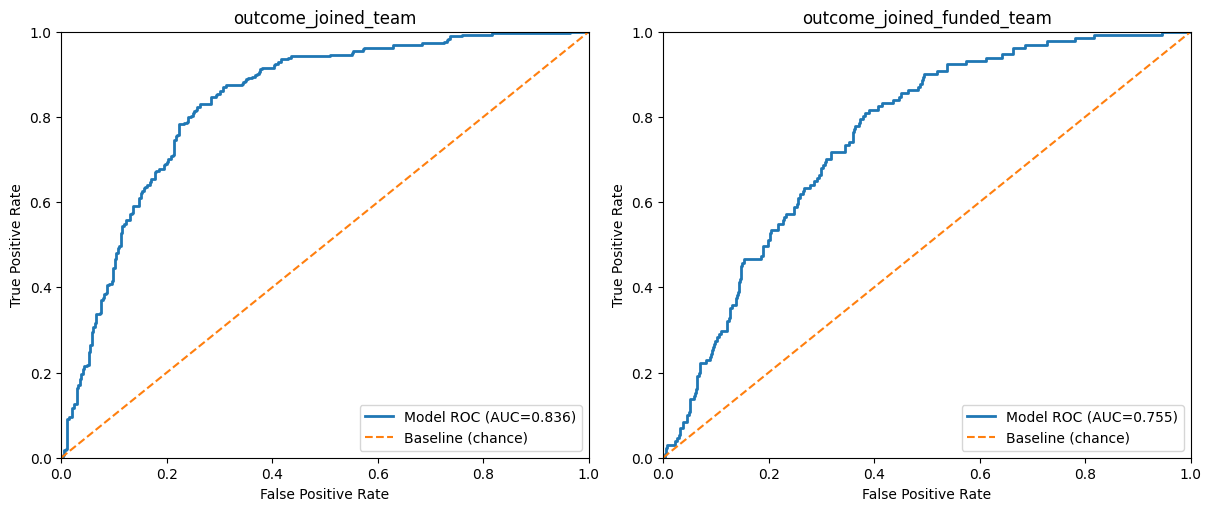

In [10]:
# ROC curves with baseline diagonal (conference-held-out predictions)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def loco_eval_scores(df, features, target):
    y_true_all, y_score_all = [], []
    for holdout in sorted(df['conference'].unique()):
        tr = df[df['conference'] != holdout]
        te = df[df['conference'] == holdout]
        if tr.empty or te.empty:
            continue
        if tr[target].nunique() < 2:
            continue
        pipe.fit(tr[features], tr[target])
        p = pipe.predict_proba(te[features])[:, 1]
        y_true_all.extend(te[target].astype(int).tolist())
        y_score_all.extend(p.tolist())
    return np.array(y_true_all), np.array(y_score_all)

targets = ['outcome_joined_team', 'outcome_joined_funded_team']
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, target in zip(axes, targets):
    y_true, y_score = loco_eval_scores(person_df, feature_cols, target)
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, f'Insufficient classes for {target}', ha='center', va='center')
        ax.set_title(target)
        continue

    auc_val = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, lw=2, label=f'Model ROC (AUC={auc_val:.3f})')
    ax.plot([0, 1], [0, 1], linestyle='--', lw=1.5, label='Baseline (chance)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(target)
    ax.legend(loc='lower right')

roc_fig_path = BASE / 'analysis_v2' / 'figures' / 'person_model_roc_curves.png'
roc_fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(roc_fig_path, dpi=150, bbox_inches='tight')
print('Saved:', roc_fig_path)
plt.show()

## Step 9 - Detailed Subcode Features

Build person-level subcode-count features from utterance annotations.


In [11]:
# Build detailed subcode features (person-within-conference)
subcode_rows = []
for conf_dir in sorted(OUTPUTS_DIR.glob('*')):
    if not conf_dir.is_dir():
        continue
    conference = conf_dir.name
    for out_dir in sorted(conf_dir.glob('output_*')):
        if not out_dir.is_dir():
            continue
        for json_path in out_dir.rglob('*.json'):
            try:
                payload = json.loads(json_path.read_text())
            except Exception:
                continue
            if not isinstance(payload, dict):
                continue
            utterances = payload.get('utterance_annotations', [])
            if not isinstance(utterances, list):
                continue

            for utt in utterances:
                if not isinstance(utt, dict):
                    continue
                speaker = resolve_alias(norm_name(utt.get('speaker')))
                pid = person_lookup.get((conference, speaker))
                if not pid:
                    continue

                for c in (utt.get('codes') or []):
                    if not isinstance(c, dict):
                        continue
                    sc = str(c.get('subcode', '')).strip().lower()
                    if not sc:
                        continue
                    sc_norm = re.sub(r'[^a-z0-9]+', '_', sc).strip('_')
                    if not sc_norm:
                        continue
                    subcode_rows.append({
                        'conference': conference,
                        'global_person_id': pid,
                        'subcode_feature': f'subcode__{sc_norm}',
                        'count': 1,
                    })

if subcode_rows:
    subcode_df = pd.DataFrame(subcode_rows)
    subcode_pivot = (
        subcode_df
        .groupby(['conference', 'global_person_id', 'subcode_feature'], as_index=False)['count'].sum()
        .pivot_table(index=['conference', 'global_person_id'], columns='subcode_feature', values='count', fill_value=0)
        .reset_index()
    )
    subcode_pivot.columns.name = None
else:
    subcode_pivot = pd.DataFrame(columns=['conference', 'global_person_id'])

person_df_detailed = person_df.merge(subcode_pivot, on=['conference', 'global_person_id'], how='left')
subcode_cols = [c for c in person_df_detailed.columns if c.startswith('subcode__')]
if subcode_cols:
    person_df_detailed[subcode_cols] = person_df_detailed[subcode_cols].fillna(0)

# requested naming
person_df_detailed['n_sessions_attended'] = person_df_detailed['n_sessions_seen']

detailed_path = TABLES_DIR / 'person_features_detailed_subcodes.csv'
person_df_detailed.to_csv(detailed_path, index=False)
print('Saved:', detailed_path)
print('Detailed subcode feature count:', len(subcode_cols))
person_df_detailed[['conference', 'global_person_id', 'normalized_name', 'n_sessions_attended'] + subcode_cols[:5]].head()

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data/person_features_detailed_subcodes.csv
Detailed subcode feature count: 70


,conference,global_person_id,normalized_name,n_sessions_attended,subcode__ambiguous,subcode__asks_clarifying_question,subcode__asks_factual_question,subcode__asks_for_elaboration,subcode__asks_for_opinion
0,2020NES,person_0001,andrew feig,5,0.0,0.0,0.0,0.0,1.0
1,2020NES,person_0002,richard wiener,3,0.0,0.0,0.0,0.0,0.0
2,2020NES,person_0003,silvia ronco,1,0.0,0.0,0.0,0.0,0.0
3,2020NES,person_0013,adam holewinski,3,14.0,3.0,0.0,0.0,2.0
4,2020NES,person_0016,alissa park,2,22.0,3.0,5.0,0.0,1.0


## Step 10 - Single-Subcode Screening

Compare controls-only models against controls plus one detailed subcode at a time.


In [12]:
# Controls-only vs controls+single-subcode (LOCO) results
controls = [c for c in ['n_sessions_attended', 'speaking_seconds_total'] if c in person_df_detailed.columns]
targets = ['outcome_joined_team', 'outcome_joined_funded_team']
subcode_cols = [c for c in person_df_detailed.columns if c.startswith('subcode__')]

# keep only sufficiently present subcodes
min_total_count = 10
subcode_cols = [c for c in subcode_cols if person_df_detailed[c].sum() >= min_total_count]

pipe_sub = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced')),
])

def loco_eval_feats(df, feature_list, target):
    y_true_all, y_score_all = [], []
    for holdout in sorted(df['conference'].unique()):
        tr = df[df['conference'] != holdout]
        te = df[df['conference'] == holdout]
        if tr.empty or te.empty:
            continue
        if tr[target].nunique() < 2:
            continue
        X_tr = tr[feature_list]
        X_te = te[feature_list]
        y_tr = tr[target].astype(int)
        y_te = te[target].astype(int)
        pipe_sub.fit(X_tr, y_tr)
        p = pipe_sub.predict_proba(X_te)[:, 1]
        y_true_all.extend(y_te.tolist())
        y_score_all.extend(p.tolist())
    if len(set(y_true_all)) < 2:
        return np.nan, np.nan
    return roc_auc_score(y_true_all, y_score_all), average_precision_score(y_true_all, y_score_all)

rows = []
for target in targets:
    base_auc, base_auprc = loco_eval_feats(person_df_detailed, controls, target)
    rows.append({
        'target': target,
        'feature_type': 'controls_only',
        'feature_name': '__controls__',
        'auc_loco': base_auc,
        'auprc_loco': base_auprc,
        'delta_auc_vs_controls': 0.0,
        'delta_auprc_vs_controls': 0.0,
    })

    for sc in subcode_cols:
        feats = controls + [sc]
        auc, auprc = loco_eval_feats(person_df_detailed, feats, target)
        rows.append({
            'target': target,
            'feature_type': 'single_subcode_plus_controls',
            'feature_name': sc,
            'auc_loco': auc,
            'auprc_loco': auprc,
            'delta_auc_vs_controls': auc - base_auc if pd.notna(auc) and pd.notna(base_auc) else np.nan,
            'delta_auprc_vs_controls': auprc - base_auprc if pd.notna(auprc) and pd.notna(base_auprc) else np.nan,
        })

detailed_results_df = pd.DataFrame(rows)
detailed_results_path = TABLES_DIR / 'person_model_detailed_subcode_results.csv'
detailed_results_df.to_csv(detailed_results_path, index=False)
detailed_results_df.to_csv(TABLES_DIR / "detailed_subcode_results.csv", index=False)
print('Saved:', detailed_results_path)

for target in targets:
    print(f'\\nTop subcodes by delta AUC for {target}:')
    display(
        detailed_results_df[
            (detailed_results_df['target'] == target) &
            (detailed_results_df['feature_type'] == 'single_subcode_plus_controls')
        ]
        .sort_values('delta_auc_vs_controls', ascending=False)
        .head(10)
    )

detailed_results_df.head()

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data/person_model_detailed_subcode_results.csv
\nTop subcodes by delta AUC for outcome_joined_team:


,target,feature_type,feature_name,auc_loco,auprc_loco,delta_auc_vs_controls,delta_auprc_vs_controls
34,outcome_joined_team,single_subcode_plus_controls,subcode__proposes_process,0.846347,0.770605,0.152913,0.199627
27,outcome_joined_team,single_subcode_plus_controls,subcode__invites_contribution,0.829991,0.748862,0.136557,0.177885
15,outcome_joined_team,single_subcode_plus_controls,subcode__encourages_participation,0.766746,0.668753,0.073312,0.097776
18,outcome_joined_team,single_subcode_plus_controls,subcode__expresses_appreciation,0.758109,0.664727,0.064675,0.093749
20,outcome_joined_team,single_subcode_plus_controls,subcode__extends_existing_idea,0.748812,0.665187,0.055378,0.094209
26,outcome_joined_team,single_subcode_plus_controls,subcode__individual_framing,0.748053,0.636782,0.054619,0.065805
38,outcome_joined_team,single_subcode_plus_controls,subcode__redirects_speaker,0.741063,0.631687,0.047629,0.060710
32,outcome_joined_team,single_subcode_plus_controls,subcode__proposes_new_idea,0.740373,0.636829,0.046939,0.065852
8,outcome_joined_team,single_subcode_plus_controls,subcode__calls_for_decision,0.738430,0.614859,0.044997,0.043882
33,outcome_joined_team,single_subcode_plus_controls,subcode__proposes_next_step,0.737425,0.621759,0.043991,0.050782


\nTop subcodes by delta AUC for outcome_joined_funded_team:


,target,feature_type,feature_name,auc_loco,auprc_loco,delta_auc_vs_controls,delta_auprc_vs_controls
94,outcome_joined_funded_team,single_subcode_plus_controls,subcode__proposes_process,0.786440,0.402623,0.103189,0.106700
87,outcome_joined_funded_team,single_subcode_plus_controls,subcode__invites_contribution,0.773216,0.388875,0.089965,0.092952
75,outcome_joined_funded_team,single_subcode_plus_controls,subcode__encourages_participation,0.741284,0.361698,0.058033,0.065775
78,outcome_joined_funded_team,single_subcode_plus_controls,subcode__expresses_appreciation,0.729188,0.341236,0.045937,0.045313
93,outcome_joined_funded_team,single_subcode_plus_controls,subcode__proposes_next_step,0.723027,0.333472,0.039776,0.037549
86,outcome_joined_funded_team,single_subcode_plus_controls,subcode__individual_framing,0.722291,0.368589,0.039039,0.072666
80,outcome_joined_funded_team,single_subcode_plus_controls,subcode__extends_existing_idea,0.713049,0.362004,0.029798,0.066081
108,outcome_joined_funded_team,single_subcode_plus_controls,subcode__shares_domain_knowledge,0.712328,0.348255,0.029077,0.052332
113,outcome_joined_funded_team,single_subcode_plus_controls,subcode__summarizes_for_group,0.710540,0.319566,0.027289,0.023643
115,outcome_joined_funded_team,single_subcode_plus_controls,subcode__synthesizes_contributions,0.705866,0.316784,0.022615,0.020862


,target,feature_type,feature_name,auc_loco,auprc_loco,delta_auc_vs_controls,delta_auprc_vs_controls
0,outcome_joined_team,controls_only,__controls__,0.693434,0.570977,0.000000,0.000000
1,outcome_joined_team,single_subcode_plus_controls,subcode__ambiguous,0.699527,0.580682,0.006093,0.009704
2,outcome_joined_team,single_subcode_plus_controls,subcode__asks_clarifying_question,0.691176,0.568277,-0.002258,-0.002700
3,outcome_joined_team,single_subcode_plus_controls,subcode__asks_factual_question,0.690348,0.571296,-0.003086,0.000319
4,outcome_joined_team,single_subcode_plus_controls,subcode__asks_for_elaboration,0.701499,0.585674,0.008065,0.014697


## Step 11 - Publication-Style Person Model Figures

Regenerate person-model summary tables and figures used in the current reporting folder.


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Saved summary: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data/person-aggregation-features/person_model_visualization_summary.csv
                    target  n_rows  feature_count  accuracy_loco_pooled  f1_loco_pooled  auc_loco_pooled  auprc_loco_pooled                                                                                                                                                       behavior_figure_path                                                                                                                                                   model_figure_path                                                                                                                                                       coef_table_path
       outcome_joined_team     639             61              0.780908        0.753521         0.858030           0.807416        /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figur

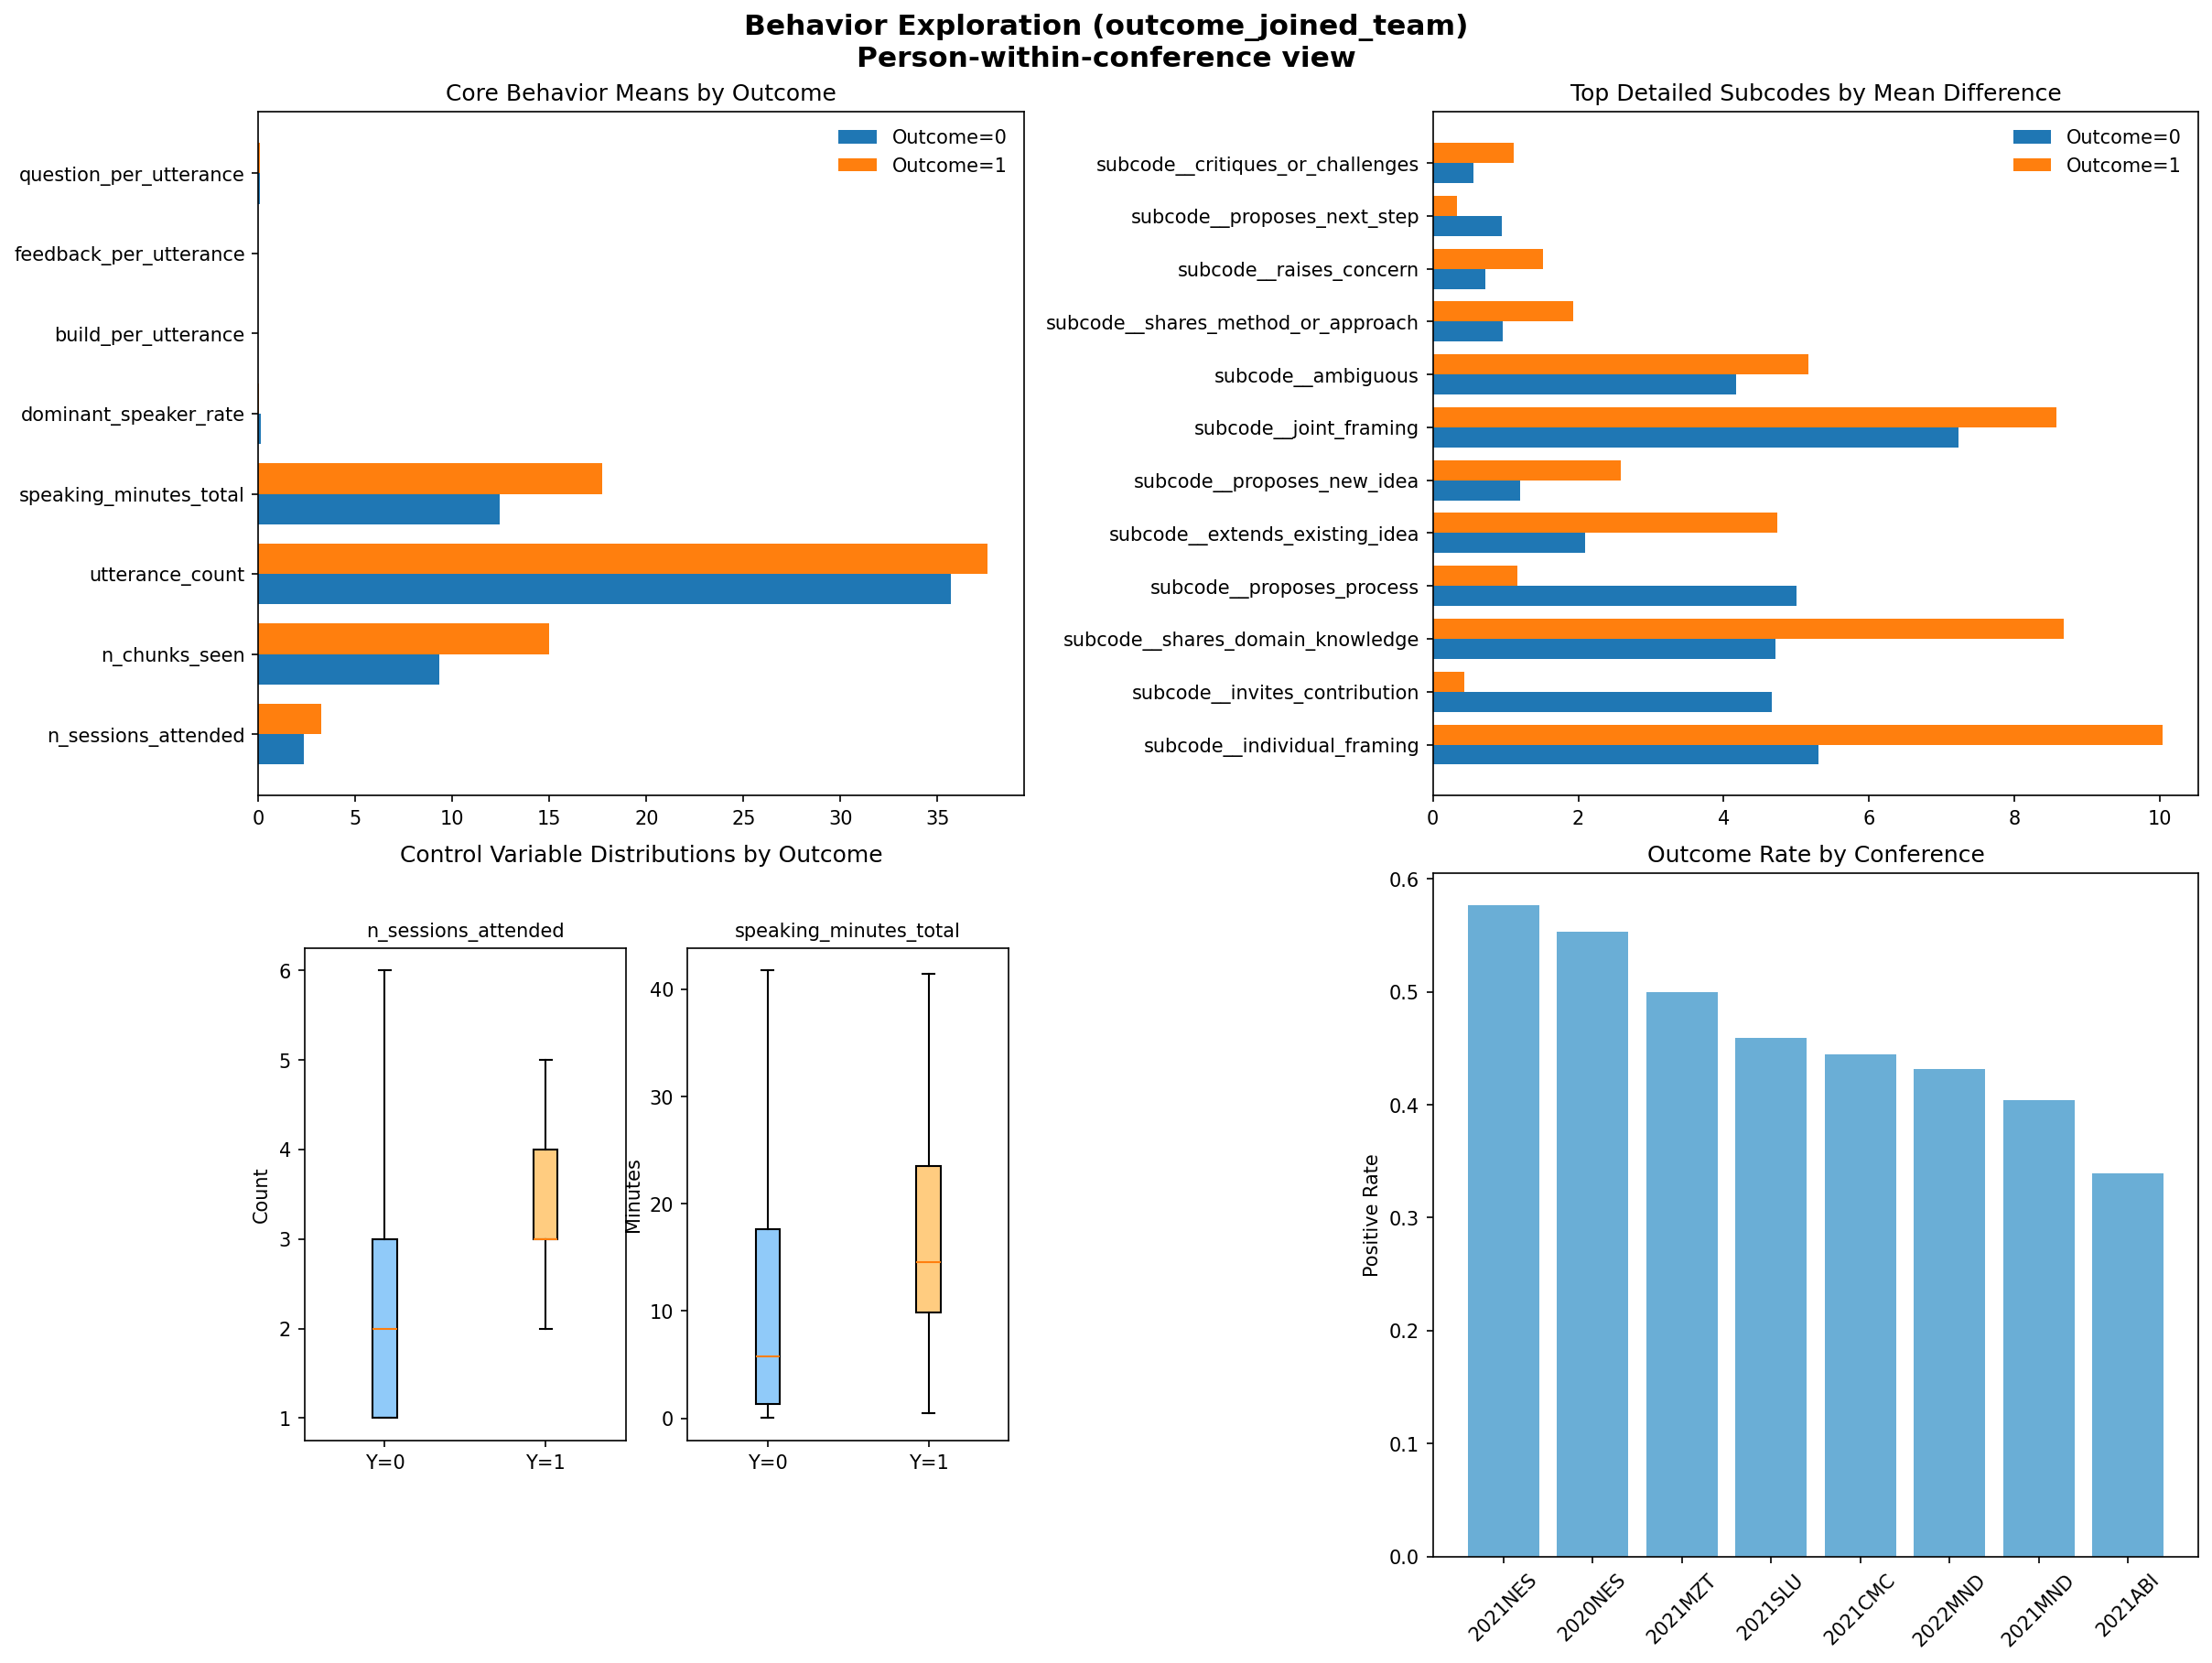

/Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/person_behavior_exploration_outcome_joined_funded_team.png


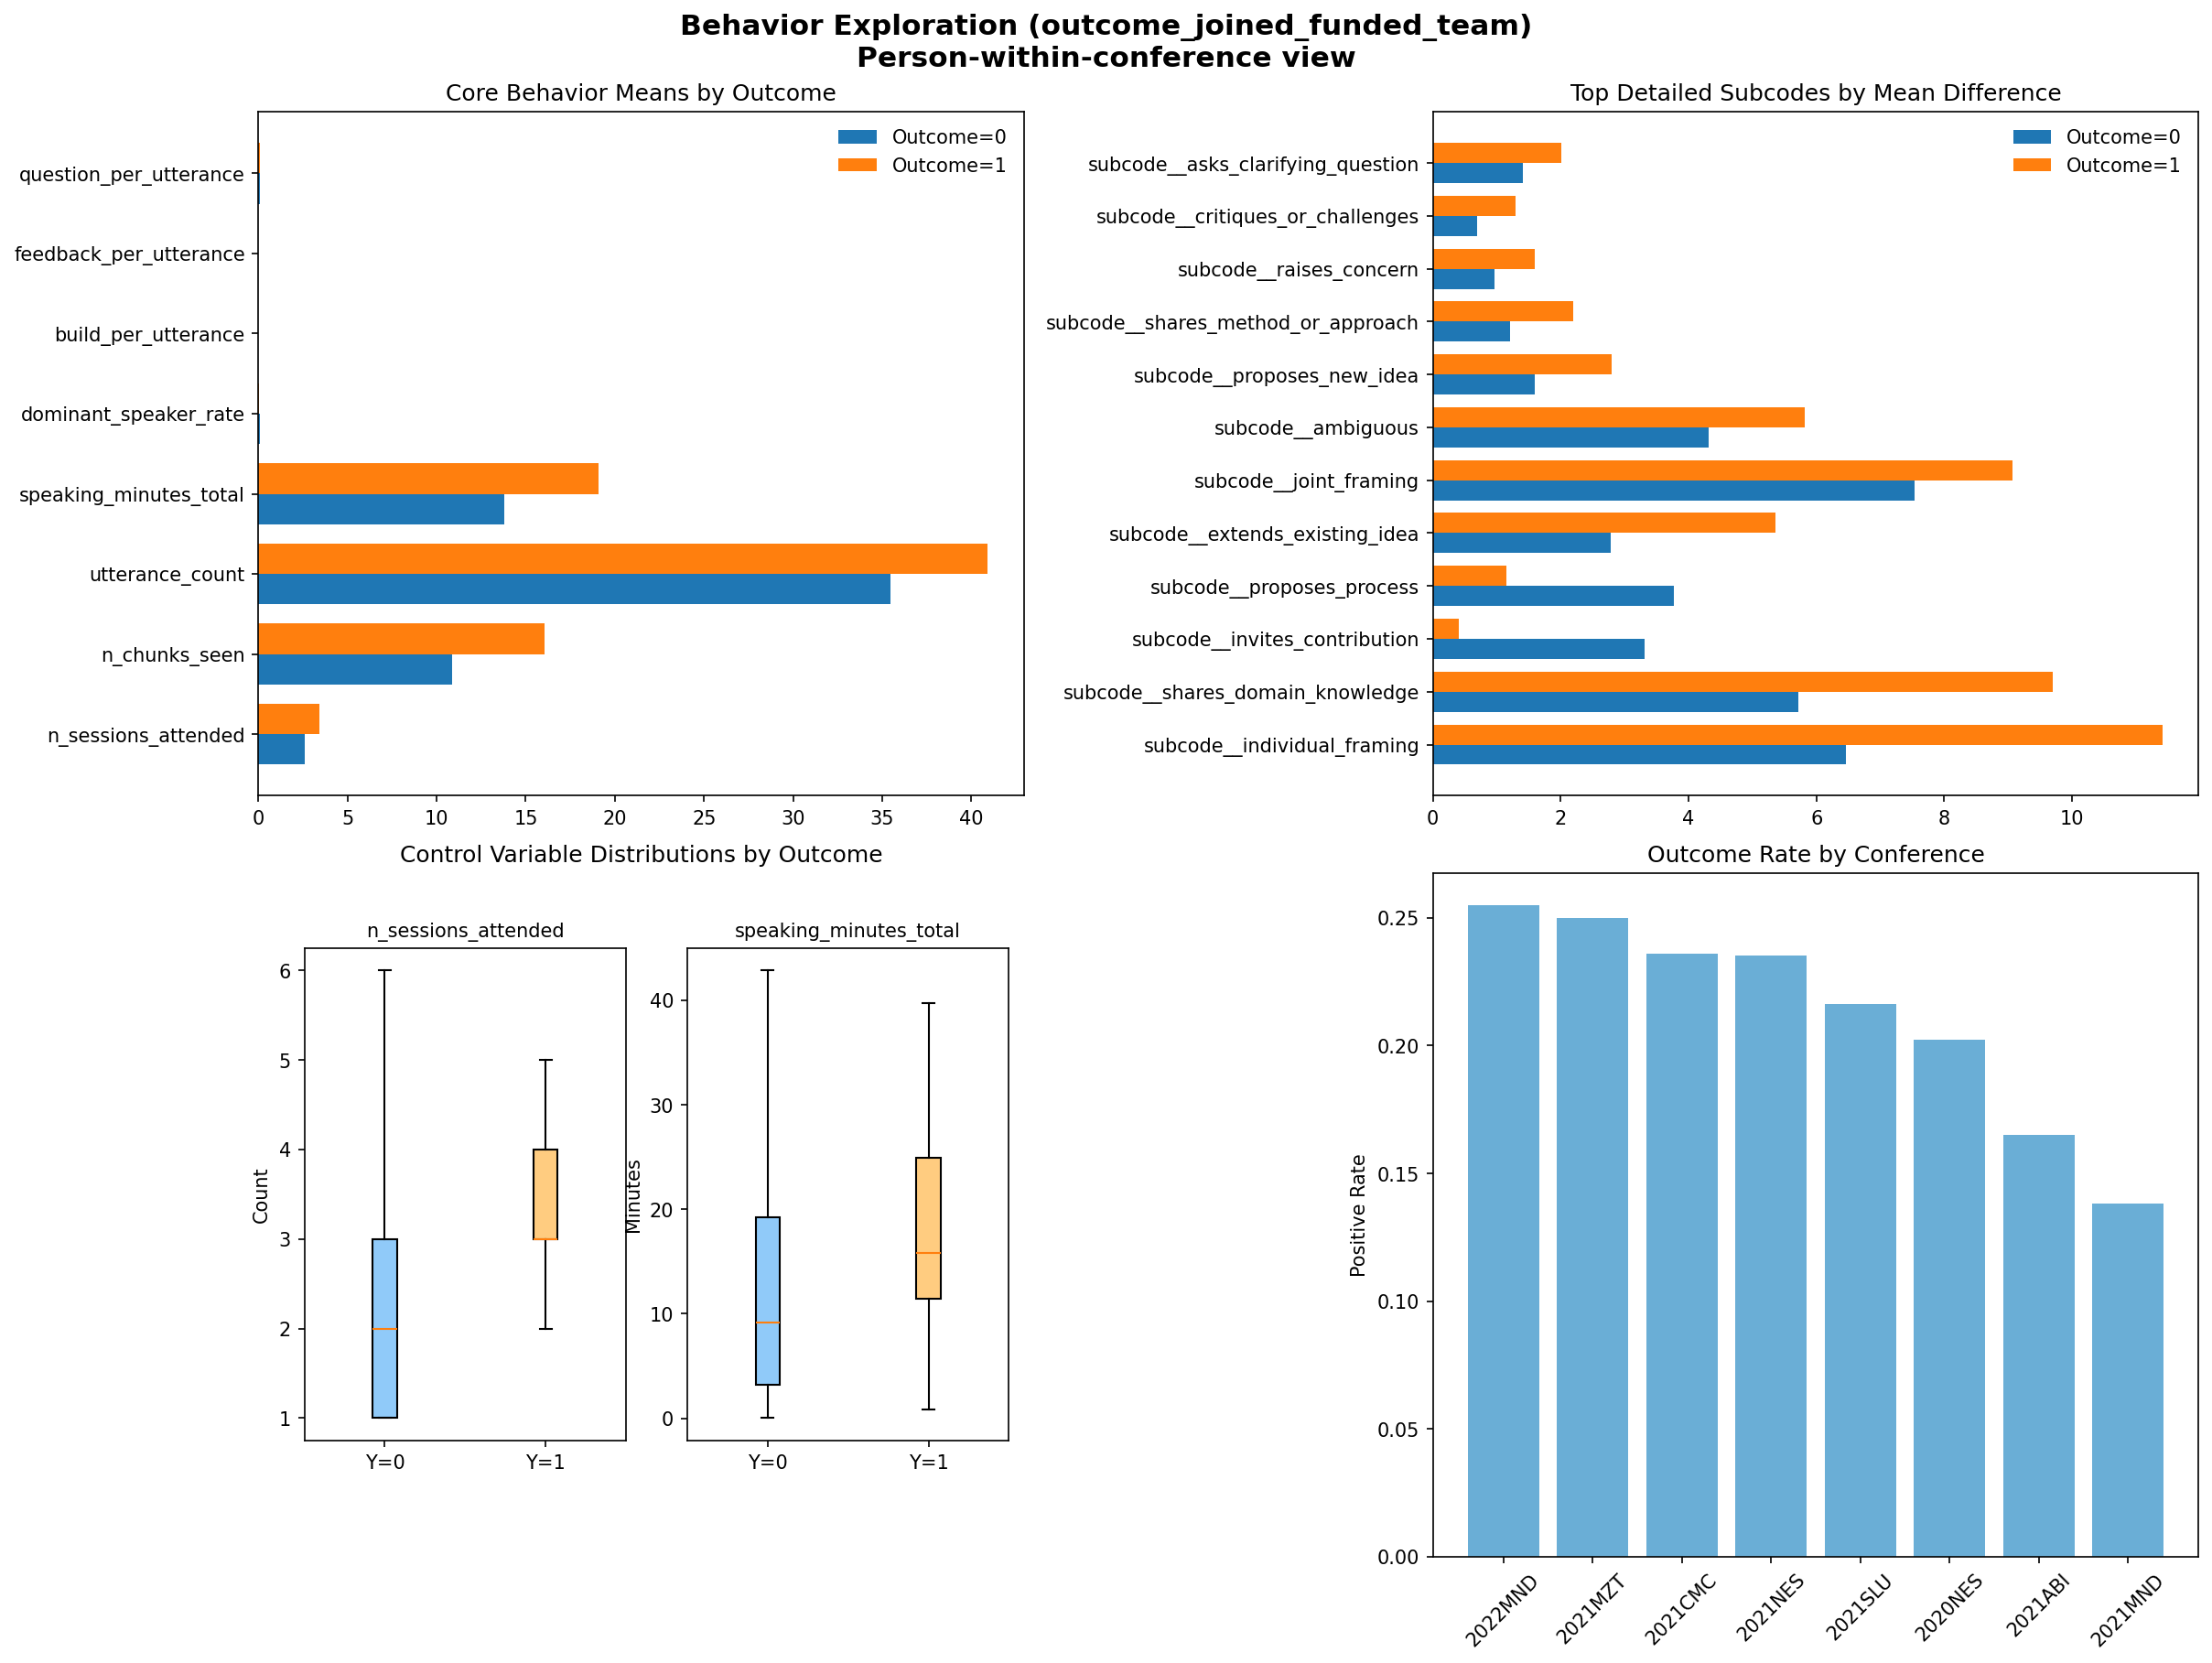

/Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/person_model_results_outcome_joined_team.png


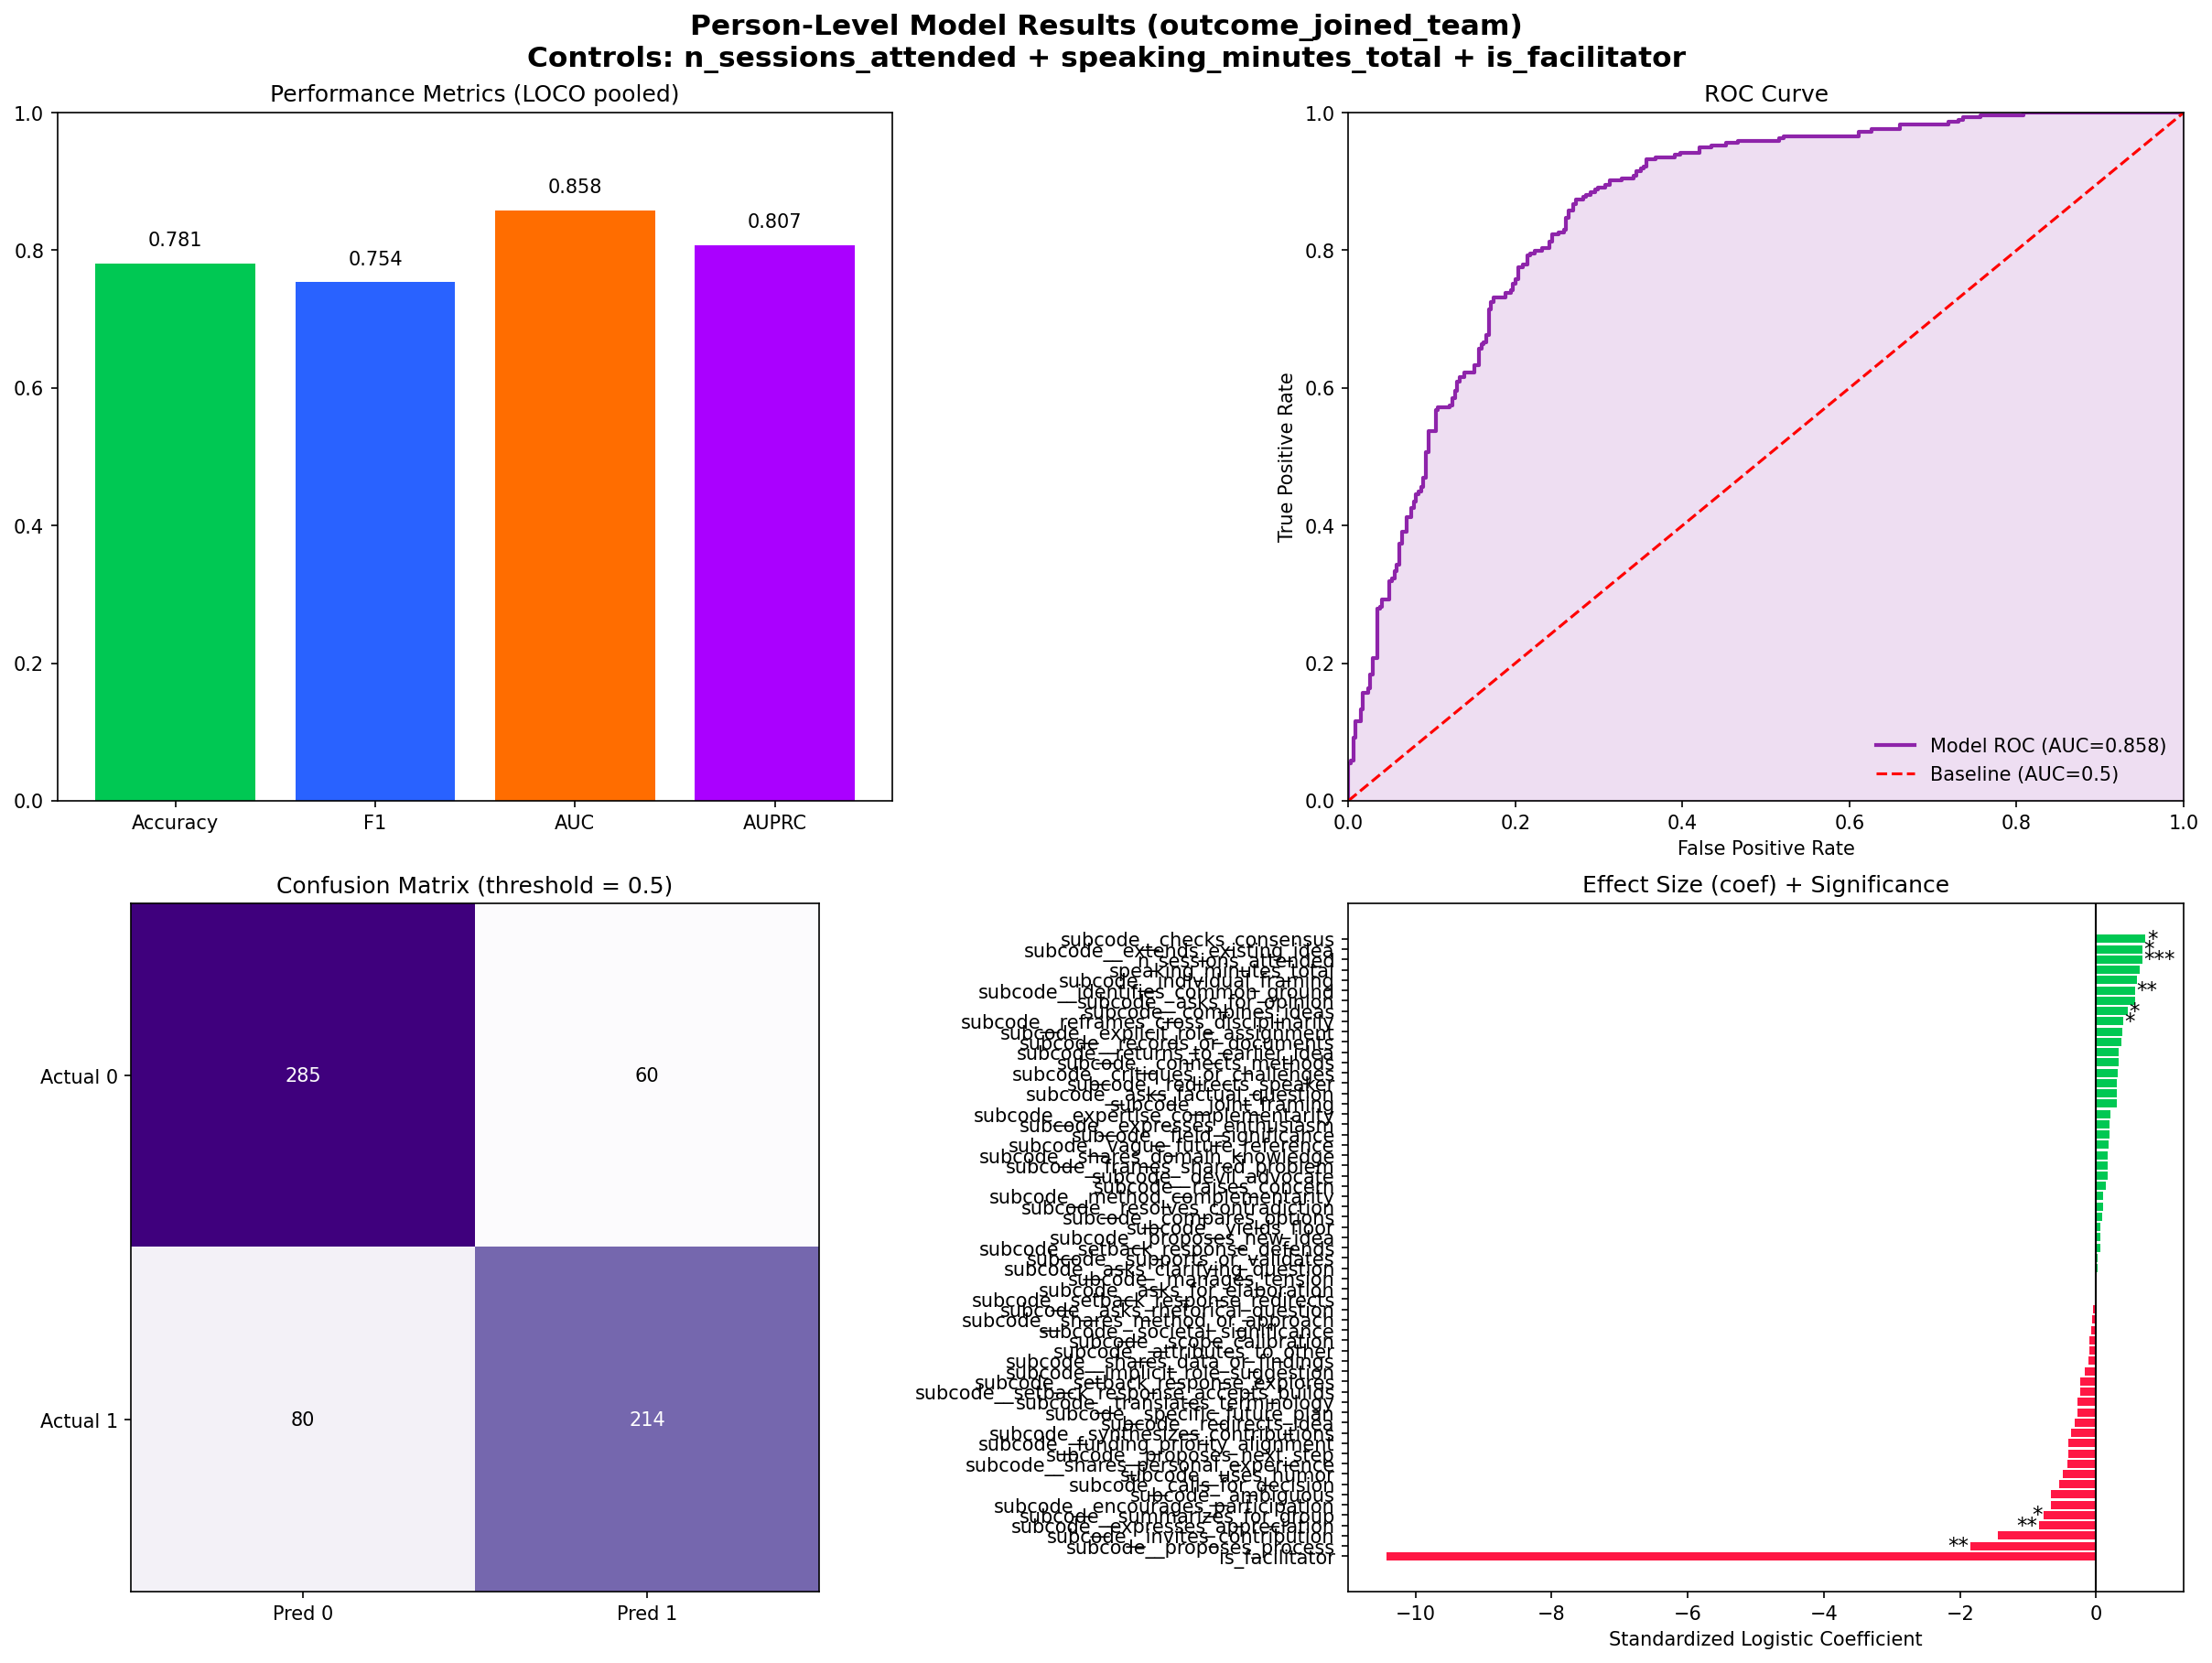

/Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/person_model_results_outcome_joined_funded_team.png


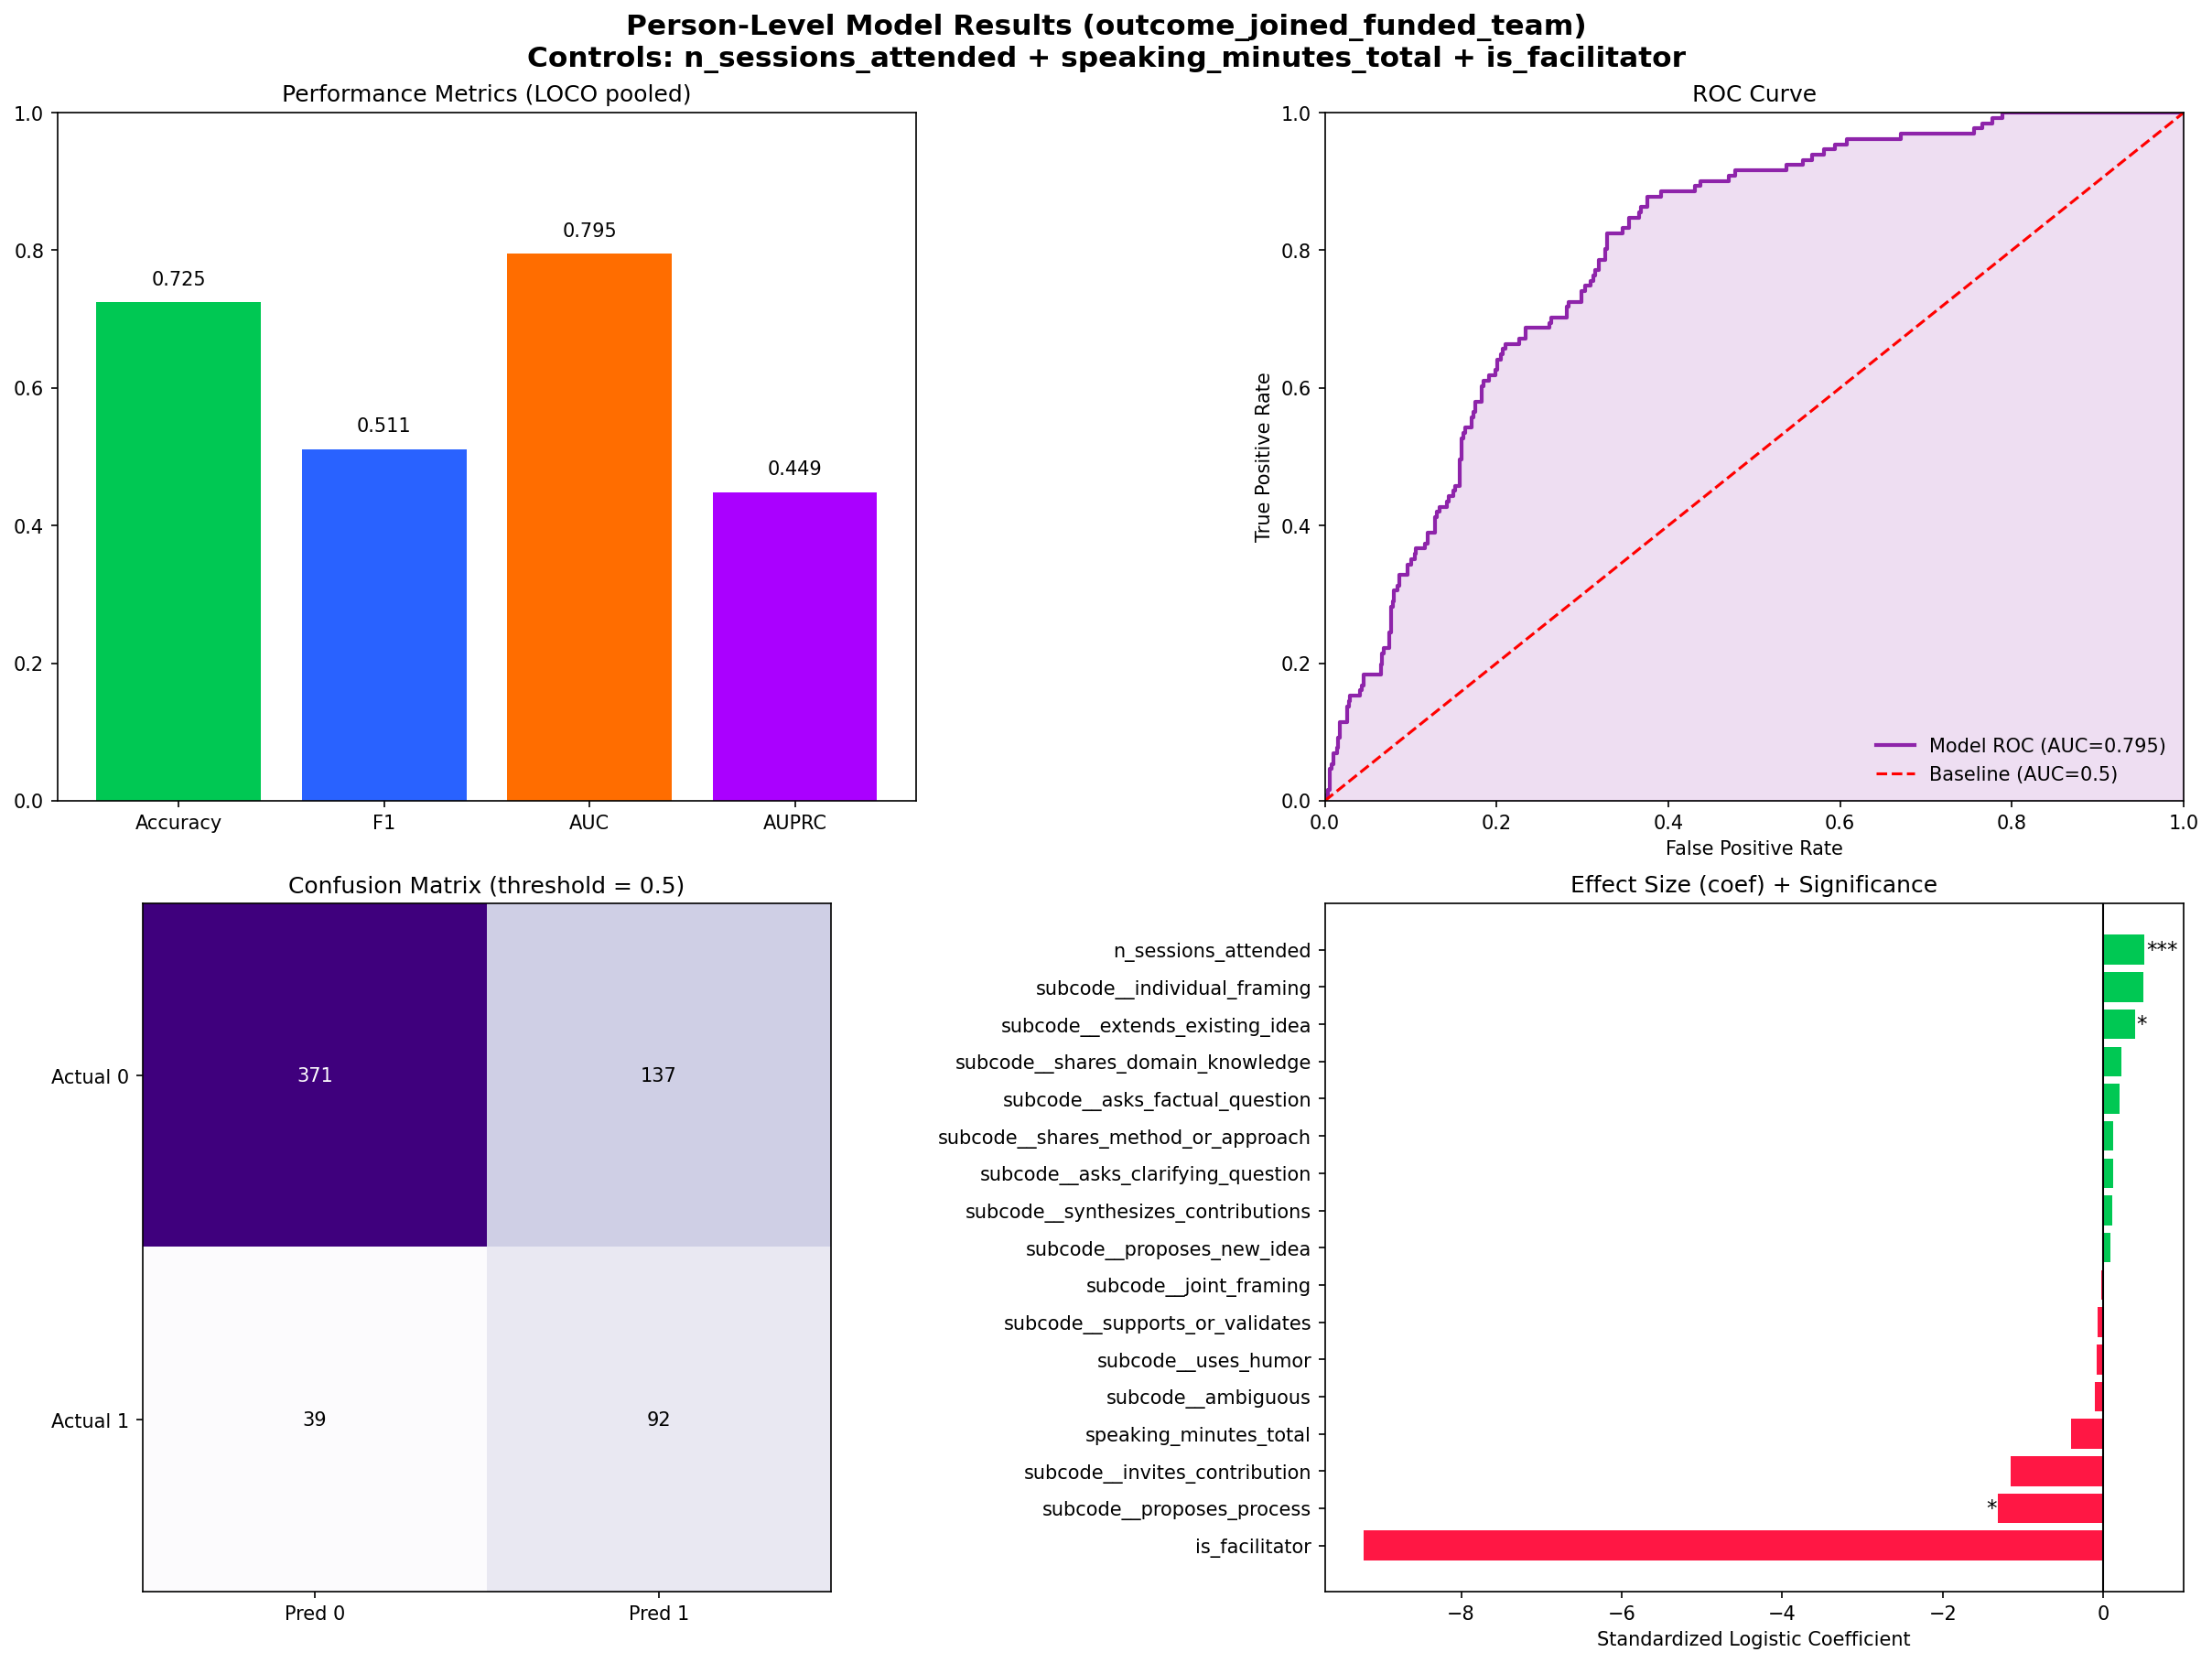

In [13]:
# Regenerate and display publication-style figures (overwrites same filenames)
import subprocess
from IPython.display import Image, display

SCRIPT_PATH = BASE / 'analysis_v2' / 'src' / 'person_visualizations.py'
subprocess.run(['python3', str(SCRIPT_PATH)], check=True)

FIG_DIR = BASE / 'analysis_v2' / 'figures' / 'person-aggregation-features'
for name in [
    'person_behavior_exploration_outcome_joined_team.png',
    'person_behavior_exploration_outcome_joined_funded_team.png',
    'person_model_results_outcome_joined_team.png',
    'person_model_results_outcome_joined_funded_team.png',
]:
    p = FIG_DIR / name
    print(p)
    display(Image(filename=str(p)))


## Presentation Figure - Significant Non-Facilitator Behaviors

Slide-specific export retained because it is one of the current reporting assets.


Saved PNG: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/figures/person_level_modeling/slide12_chart_300dpi.png
Saved PDF: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/figures/person_level_modeling/slide12_chart.pdf


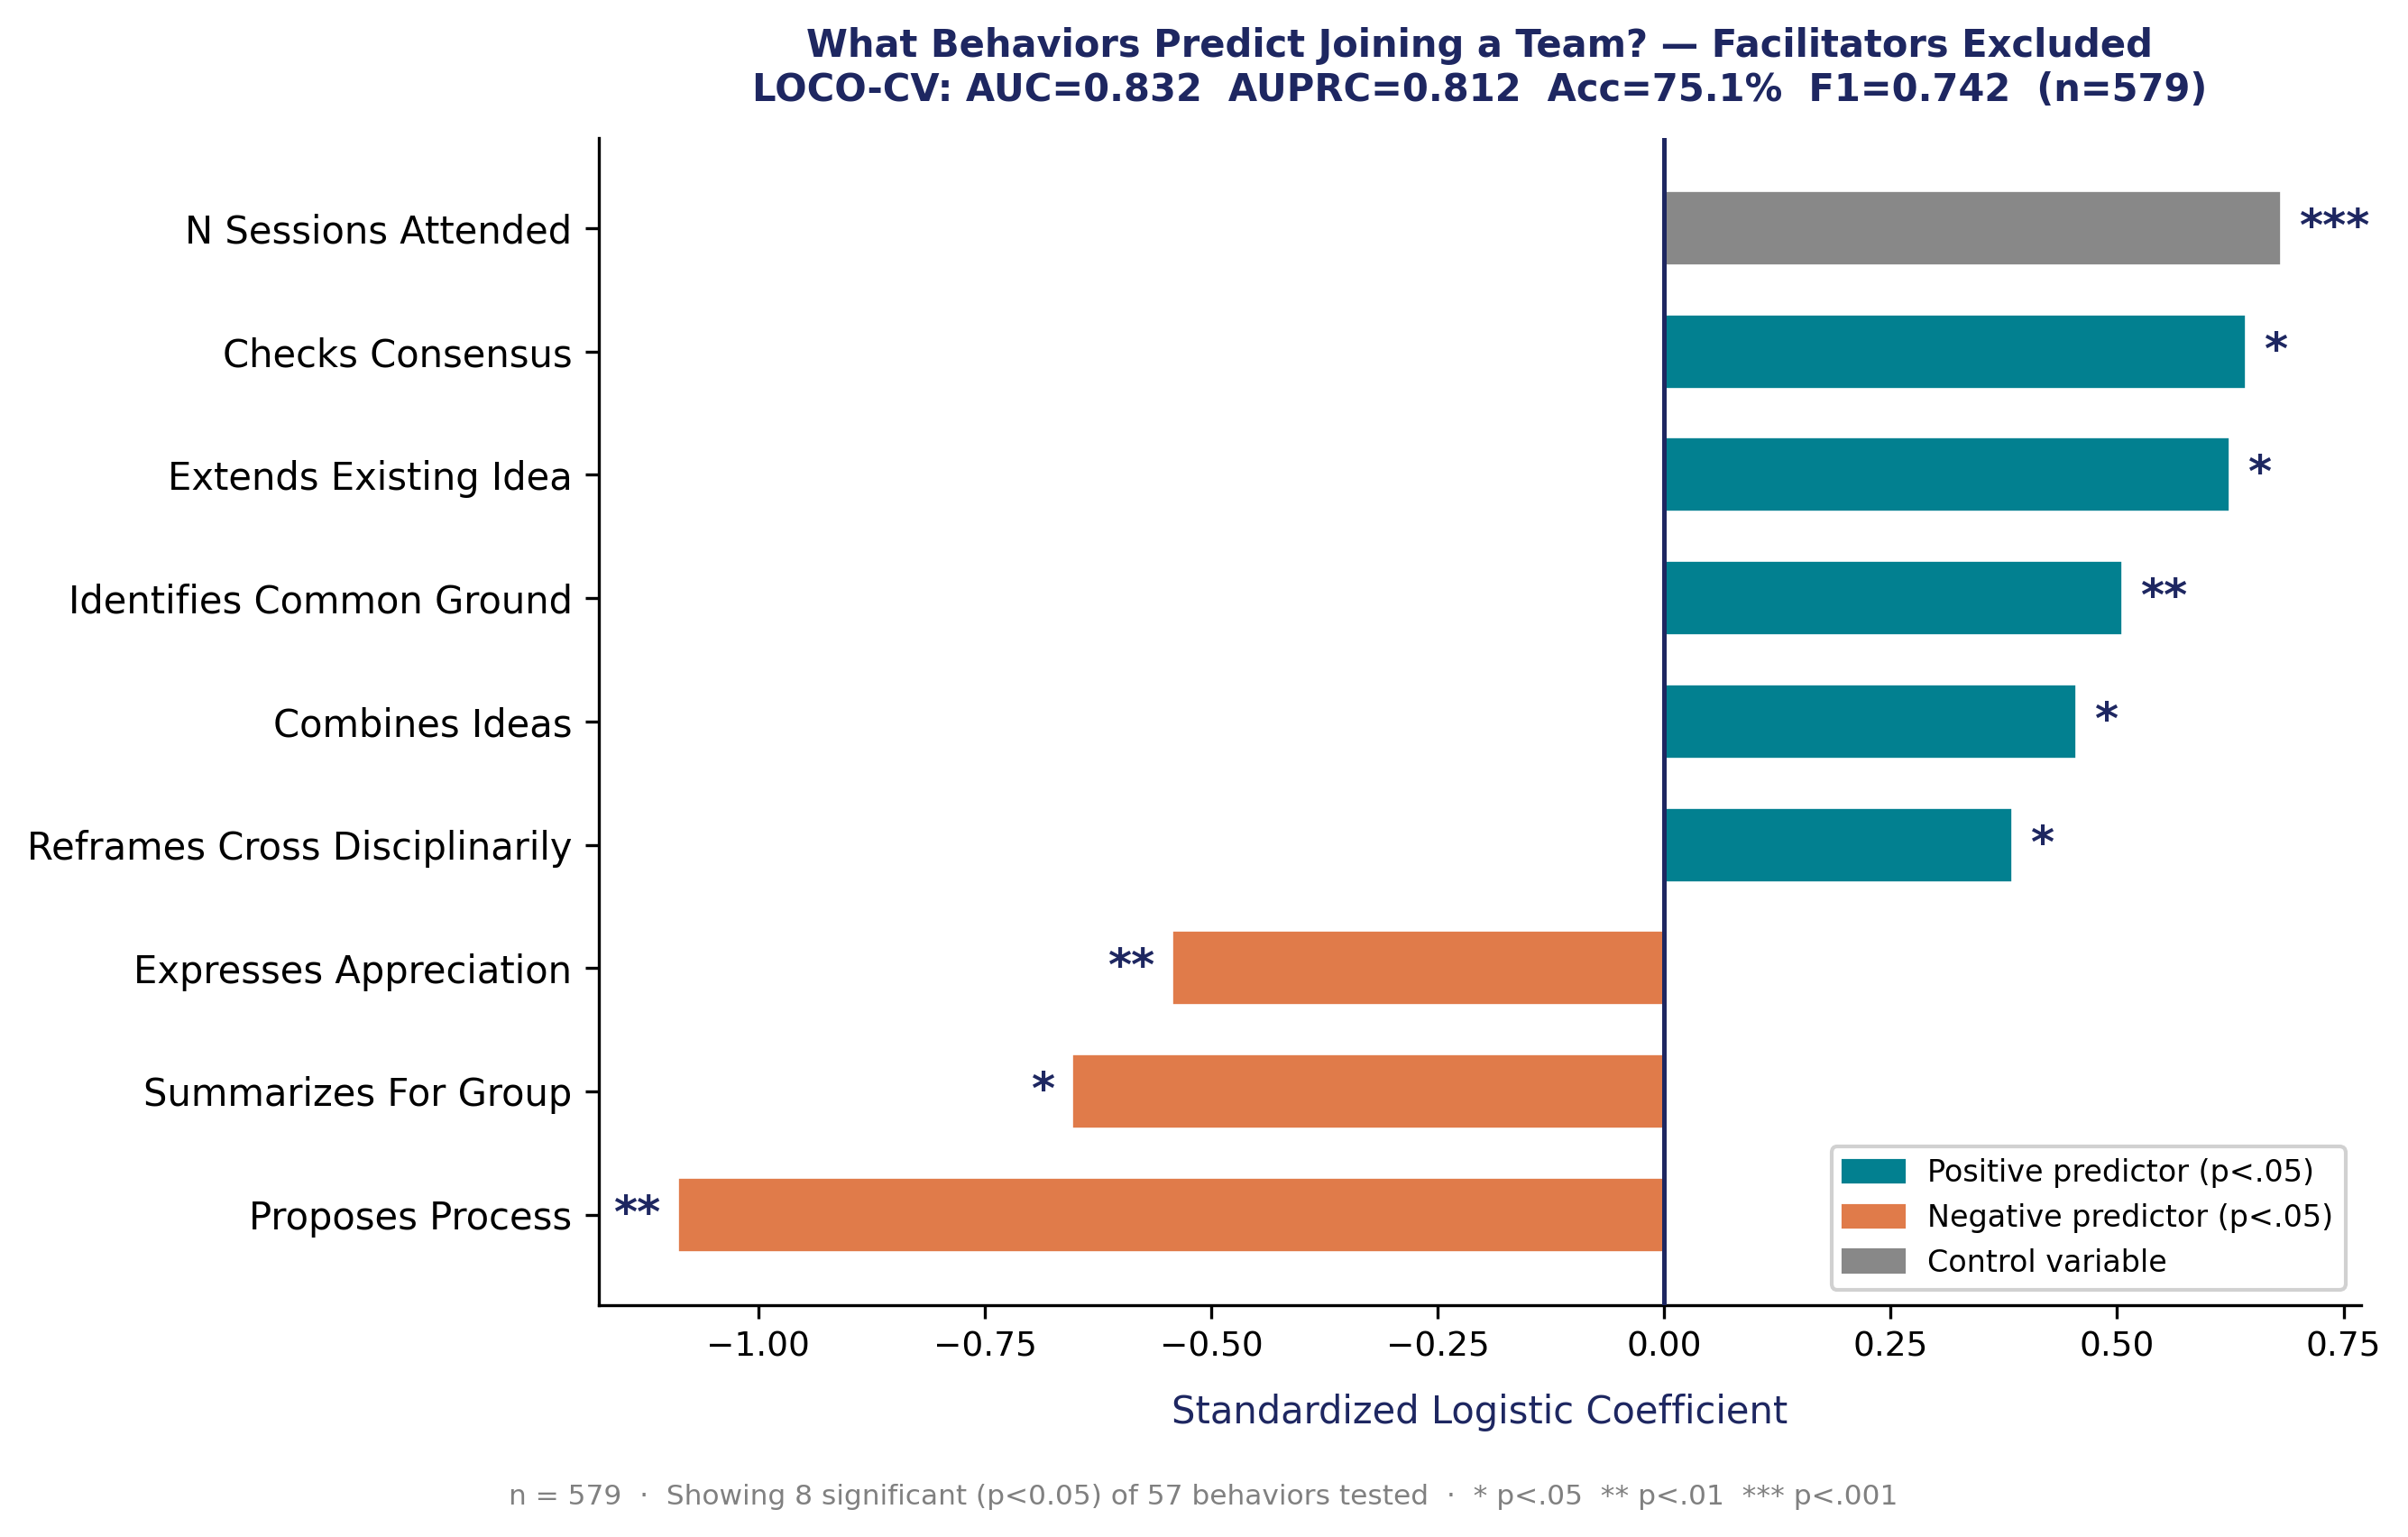

In [14]:
# ── Slide 12: significant-behaviors chart (non-facilitators, p<0.05) ──────────
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

NAVY     = "#1E2761"
TEAL     = "#028090"
ORANGE   = "#E07B4A"
GRAY     = "#888888"

FEAT_DIR = BASE / "analysis_v2" / "data" / "person-aggregation-features"
FIG_DIR  = FIGURES_DIR

coefs    = pd.read_csv(FEAT_DIR / "person_model_coefs_nonfac_subcode.csv")
ctrl_row = coefs[coefs["feature"] == "n_sessions_attended"].iloc[0]
sig_df   = coefs[
    (coefs["pvalue"] < 0.05) &
    (~coefs["feature"].isin(["n_sessions_attended", "speaking_minutes_total"]))
].copy()

sig_df["label"] = (sig_df["feature"]
    .str.replace("subcode__", "")
    .str.replace("_", " ")
    .str.title())

ctrl_entry = pd.DataFrame([{
    "feature": "n_sessions_attended",
    "coef": ctrl_row["coef"],
    "pvalue": ctrl_row["pvalue"],
    "stars": ctrl_row["stars"],
    "label": "N Sessions Attended",
}])

plot_df = pd.concat([sig_df, ctrl_entry], ignore_index=True).sort_values("coef")

colors = [
    GRAY   if r["feature"] == "n_sessions_attended" else
    TEAL   if r["coef"] >= 0 else ORANGE
    for _, r in plot_df.iterrows()
]

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.barh(plot_df["label"], plot_df["coef"],
        color=colors, height=0.6, edgecolor="white", linewidth=0.4)
ax.axvline(0, color=NAVY, linewidth=1.2, zorder=3)

for yi, (_, row) in enumerate(plot_df.reset_index(drop=True).iterrows()):
    if str(row.get("stars", "")).strip():
        xp = row["coef"] + (0.02 if row["coef"] >= 0 else -0.02)
        ax.text(xp, yi, row["stars"], va="center",
                ha="left" if row["coef"] >= 0 else "right",
                fontsize=12, color=NAVY, fontweight="bold")

ax.set_xlabel("Standardized Logistic Coefficient", fontsize=10, color=NAVY, labelpad=8)
ax.set_title(
    "What Behaviors Predict Joining a Team? — Facilitators Excluded\n"
    "LOCO-CV: AUC=0.832  AUPRC=0.812  Acc=75.1%  F1=0.742  (n=579)",
    fontsize=10, fontweight="bold", color=NAVY, pad=10,
)

ax.legend(handles=[
    mpatches.Patch(color=TEAL,   label="Positive predictor (p<.05)"),
    mpatches.Patch(color=ORANGE, label="Negative predictor (p<.05)"),
    mpatches.Patch(color=GRAY,   label="Control variable"),
], loc="lower right", frameon=True, framealpha=0.9, fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9)
fig.tight_layout()
fig.text(0.5, -0.02,
         f"n = 579  ·  Showing {len(sig_df)} significant (p<0.05) of 57 behaviors tested"
         "  ·  * p<.05  ** p<.01  *** p<.001",
         ha="center", fontsize=7.5, color="gray")

png_path = FIGURES_DIR / "slide12_chart_300dpi.png"
pdf_path = FIGURES_DIR / "slide12_chart.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path,          bbox_inches="tight")
plt.close()
print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")
display(Image(filename=str(png_path)))

## Presentation Figure - Speaker Role Signals

Slide-specific export retained because it is one of the current reporting assets.


Saved PNG: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/figures/person_level_modeling/slide22_chart_300dpi.png
Saved PDF: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/figures/person_level_modeling/slide22_chart.pdf


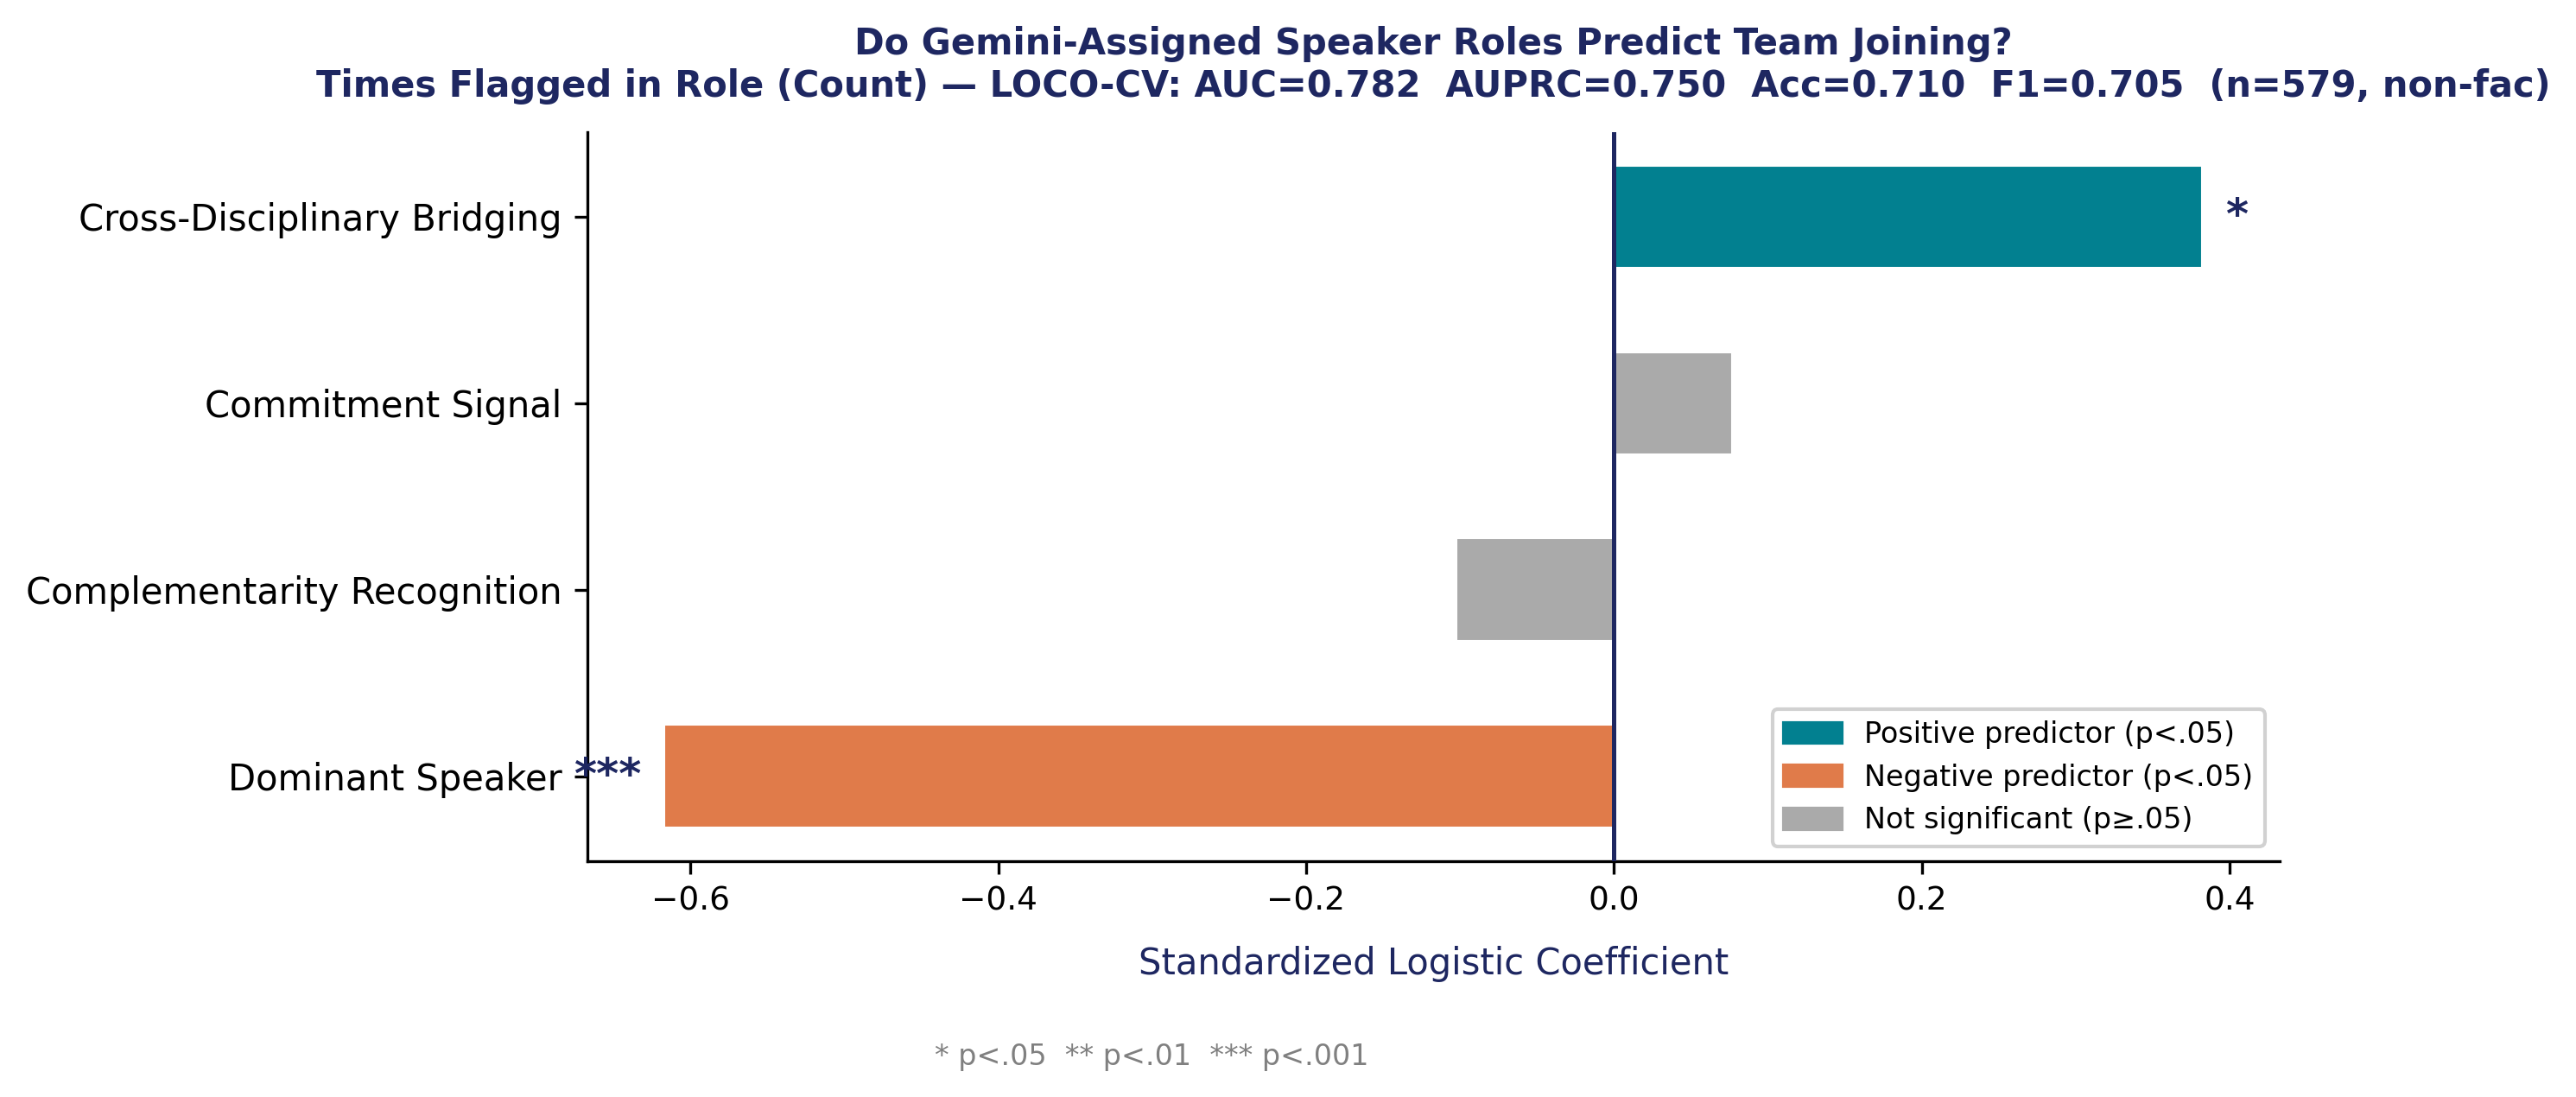

In [15]:
# ── Slide 22: Gemini-assigned speaker roles predict team joining ───────────────
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

NAVY     = "#1E2761"
TEAL     = "#028090"
ORANGE   = "#E07B4A"
GRAY     = "#AAAAAA"

FEAT_DIR = BASE / "analysis_v2" / "data" / "person-aggregation-features"

coefs = pd.read_csv(FEAT_DIR / "person_role_speaker_coefs_count.csv")

ROLE_COLS = ["n_dominant_speaker", "n_complementarity_recognition",
             "n_cross_disciplinary_bridging", "n_commitment_signal"]

plot_df = coefs[coefs["feature"].isin(ROLE_COLS)].copy().sort_values("coef")

colors = [
    TEAL   if (r["coef"] >= 0 and r["pvalue"] < 0.05) else
    ORANGE if (r["coef"] <  0 and r["pvalue"] < 0.05) else GRAY
    for _, r in plot_df.iterrows()
]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.barh(plot_df["label"], plot_df["coef"],
        color=colors, height=0.55, edgecolor="white", linewidth=0.5)
ax.axvline(0, color=NAVY, linewidth=1.2, zorder=3)

for yi, (_, row) in enumerate(plot_df.reset_index(drop=True).iterrows()):
    stars = row.get("stars", "")
    if pd.isna(stars) or str(stars).strip() in ("", "nan", "NaN"):
        continue
    xp = row["coef"] + (0.015 if row["coef"] >= 0 else -0.015)
    ax.text(xp, yi, str(stars), va="center",
            ha="left" if row["coef"] >= 0 else "right",
            fontsize=12, color=NAVY, fontweight="bold")

ax.set_xlabel("Standardized Logistic Coefficient", fontsize=10, color=NAVY, labelpad=8)
ax.set_title(
    "Do Gemini-Assigned Speaker Roles Predict Team Joining?\n"
    "Times Flagged in Role (Count) — LOCO-CV: AUC=0.782  AUPRC=0.750  Acc=0.710  F1=0.705  (n=579, non-fac)",
    fontsize=10, fontweight="bold", color=NAVY, pad=10,
)
ax.legend(handles=[
    mpatches.Patch(color=TEAL,   label="Positive predictor (p<.05)"),
    mpatches.Patch(color=ORANGE, label="Negative predictor (p<.05)"),
    mpatches.Patch(color=GRAY,   label="Not significant (p≥.05)"),
], loc="lower right", frameon=True, framealpha=0.9, fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9)
fig.tight_layout()
fig.text(0.5, -0.04, "* p<.05  ** p<.01  *** p<.001",
         ha="center", fontsize=8, color="gray")

png_path = FIGURES_DIR / "slide22_chart_300dpi.png"
pdf_path = FIGURES_DIR / "slide22_chart.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path,          bbox_inches="tight")
plt.close()
print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")
display(Image(filename=str(png_path)))